# Agrupamiento espectral
## Minired SP500

Aquí la red representa relaciones proveedor-cliente: una arista dirigida $u\to v$ significa que $u$ provee a $v$. Para estudiar la Laplaciana uso la versión no dirigida subyacente, porque `laplacian_spectrum`, `fiedler_vector`, `spectral_ordering` y `spectral_bisection` trabajan naturalmente con esa estructura.

La lectura económica es distinta a la de una red social: una comunidad no representa necesariamente un sector GICS, sino un bloque de dependencia. Por ejemplo, NVDA puede conectar semiconductores con plataformas cloud; AMZN puede aparecer como hub que toca streaming, salud y energía; AAPL puede entrar en un bloque de pagos/retail por sus relaciones con MA, JPM, COST o WMT.

In [1]:
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display
from networkx.algorithms.community import greedy_modularity_communities

SEED = 863

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.options.display.max_colwidth = 200

In [2]:
def get_display_labels(G):
    raw = nx.get_node_attributes(G, "label")
    return {node: raw.get(node, str(node)) for node in G.nodes()}


def rounded_list(values, digits=6):
    return [round(float(x), digits) for x in np.asarray(values, dtype=float)]


def communities_to_lookup(communities):
    lookup = {}
    for idx, community in enumerate(communities):
        for node in community:
            lookup[node] = idx
    return lookup


def algebraic_connectivity_safe(G, weight=None):
    if G.number_of_nodes() < 2 or not nx.is_connected(G):
        return 0.0
    return float(nx.algebraic_connectivity(G, weight=weight))


def spectral_report(G, labels, title, weight=None):
    print("=" * 100)
    print(title)
    print(f"nodos = {G.number_of_nodes()}, aristas = {G.number_of_edges()}, conexa = {nx.is_connected(G)}")
    spectrum = rounded_list(nx.laplacian_spectrum(G, weight=weight))
    print("laplacian_spectrum =", spectrum)
    result = {
        "title": title,
        "spectrum": spectrum,
        "groups": [set(G.nodes())],
        "lambda2": 0.0,
    }
    if not nx.is_connected(G):
        component_sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
        print("La subred no es conexa; antes de bisectar hay que separar componentes.")
        print("tamano_componentes =", component_sizes)
        return result
    lambda2 = algebraic_connectivity_safe(G, weight=weight)
    fiedler = nx.fiedler_vector(G, weight=weight)
    ordering = list(nx.spectral_ordering(G, weight=weight))
    groups = [set(part) for part in nx.spectral_bisection(G, weight=weight)]
    print(f"lambda_2 = {lambda2:.6f}")
    print("spectral_ordering =", [labels[node] for node in ordering])
    print("grupo_1 =", sorted(labels[node] for node in groups[0]))
    print("grupo_2 =", sorted(labels[node] for node in groups[1]))
    fiedler_df = (
        pd.DataFrame(
            {
                "nodo": [labels[node] for node in G.nodes()],
                "componente_fiedler": fiedler,
                "signo": np.where(fiedler >= 0, "+", "-"),
            }
        )
        .sort_values("componente_fiedler")
        .reset_index(drop=True)
    )
    display(fiedler_df.round(4))
    result.update(
        {
            "lambda2": lambda2,
            "ordering": ordering,
            "groups": groups,
            "fiedler_df": fiedler_df,
        }
    )
    return result


def partition_summary(G, communities, labels, weight=None):
    rows = []
    for idx, community in enumerate(sorted([set(c) for c in communities], key=len, reverse=True), start=1):
        SG = G.subgraph(community).copy()
        rows.append(
            {
                "grupo": idx,
                "nodos": len(community),
                "aristas_internas": SG.number_of_edges(),
                "densidad": round(nx.density(SG), 4) if len(community) > 1 else 0.0,
                "lambda_2": round(algebraic_connectivity_safe(SG, weight=weight), 4),
                "miembros": ", ".join(sorted(labels[node] for node in community)),
            }
        )
    return pd.DataFrame(rows)


def draw_partition(ax, G, communities, labels, title, pos=None):
    groups = [set(c) for c in communities]
    if pos is None:
        pos = nx.kamada_kawai_layout(G)
    lookup = communities_to_lookup(groups)
    node_colors = [lookup[node] for node in G.nodes()]
    node_sizes = [220 + 20 * G.degree(node) for node in G.nodes()]
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=1.0, edge_color="#94a3b8")
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=node_sizes,
        cmap="nipy_spectral",
        linewidths=0.8,
        edgecolors="white",
    )
    font_size = 9 if G.number_of_nodes() <= 25 else 7
    nx.draw_networkx_labels(G, pos, ax=ax, labels=labels, font_size=font_size)
    ax.set_title(title)
    ax.axis("off")
    return pos


def plot_partition_sequence(G, labels, states, pos=None, ncols=2, figsize=(18, 12)):
    if pos is None:
        pos = nx.kamada_kawai_layout(G)
    nrows = int(np.ceil(len(states) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, state in zip(axes, states):
        draw_partition(ax, G, state["groups"], labels, state["title"], pos=pos)
    for ax in axes[len(states):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def comparison_table(entries):
    return pd.DataFrame(entries).sort_values(["grafo", "Q"], ascending=[True, False]).reset_index(drop=True)

from typing import List, Tuple

V: List[str] = [
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "GOOG", "AVGO", "META", "TSLA", "BRK.B",
    "JPM", "V", "MA", "WMT", "COST", "ORCL", "LLY", "XOM", "JNJ", "PLTR",
    "BAC", "ABBV", "MU", "HD", "NFLX", "AMD", "PG", "GE", "CVX", "UNH",
]

E: List[Tuple[str, str]] = [
    ("MU", "NVDA"), ("AVGO", "AAPL"),
    ("NVDA", "MSFT"), ("NVDA", "AMZN"), ("NVDA", "GOOG"), ("NVDA", "GOOGL"),
    ("NVDA", "ORCL"), ("NVDA", "META"), ("NVDA", "TSLA"),
    ("AMD", "AMZN"), ("AMD", "MSFT"), ("AMD", "ORCL"), ("AMD", "TSLA"),
    ("AMZN", "NFLX"), ("AMZN", "XOM"), ("AMZN", "JNJ"), ("AMZN", "ABBV"), ("AMZN", "PLTR"),
    ("MSFT", "CVX"), ("MSFT", "GE"), ("MSFT", "UNH"), ("MSFT", "PLTR"),
    ("GOOGL", "PLTR"), ("ORCL", "PLTR"),
    ("AAPL", "WMT"), ("AAPL", "COST"), ("PG", "WMT"), ("BRK.B", "WMT"),
    ("V", "COST"), ("V", "HD"), ("V", "BAC"),
    ("MA", "HD"), ("MA", "WMT"), ("MA", "AAPL"), ("MA", "BAC"),
    ("JPM", "AAPL"),
    ("LLY", "AMZN"),
]

G_dir = nx.DiGraph()
G_dir.add_nodes_from(V)
G_dir.add_edges_from(E)
for node in G_dir.nodes():
    G_dir.nodes[node]["label"] = node

# Para la Laplaciana del tutorial uso la red subyacente no dirigida.
G_sp = G_dir.to_undirected()
for node in G_sp.nodes():
    G_sp.nodes[node]["label"] = node

labels_sp = get_display_labels(G_sp)
pos_sp = nx.spring_layout(G_sp, seed=SEED, k=1.2)
componentes_sp = [set(c) for c in sorted(nx.connected_components(G_sp), key=len, reverse=True)]

print(rounded_list(nx.laplacian_spectrum(G_sp)))

resumen_componentes_sp = pd.DataFrame(
    [
        {
            "componente": idx + 1,
            "nodos": len(comp),
            "lambda_2": round(algebraic_connectivity_safe(G_sp.subgraph(comp).copy()), 4),
            "miembros": ", ".join(sorted(comp)),
        }
        for idx, comp in enumerate(componentes_sp)
    ]
)

display(resumen_componentes_sp)

[-0.0, -0.0, 0.394933, 0.499826, 0.553077, 0.63612, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.182867, 1.585786, 1.704603, 2.0, 2.412673, 2.909774, 4.351097, 4.414214, 4.4595, 5.593671, 6.304908, 6.714569, 8.086994, 10.195387]


,componente,nodos,lambda_2,miembros
0,1,19,0.3949,"ABBV, AMD, AMZN, CVX, GE, GOOG, GOOGL, JNJ, LLY, META, MSFT, MU, NFLX, NVDA, ORCL, PLTR, TSLA, UNH, XOM"
1,2,11,0.4998,"AAPL, AVGO, BAC, BRK.B, COST, HD, JPM, MA, PG, V, WMT"


La red completa no es conexa y tiene dos componentes; por eso el espectro tiene dos ceros y la bisección espectral no se aplica directamente a todo el grafo.

Separo componentes y luego decido cuáles siguen siendo candidatas a subdividir, guiándome por su conectividad algebraica $\lambda_2$.

Interpretación inicial:

- la componente de 19 nodos agrupa tecnología/plataformas, semiconductores, cloud y empresas conectadas a AMZN/MSFT/NVDA;
- la componente de 11 nodos agrupa consumo, retail, pagos y banca alrededor de AAPL, WMT, V, MA, JPM y BAC;
- la desconexión entre componentes no significa que no haya relación económica real entre esas firmas, sino que en esta minired concreta no hay una arista proveedor-cliente que conecte ambos bloques.

## 1. Componentes candidatas a dividir

In [3]:
G_sp_c1 = G_sp.subgraph(componentes_sp[0]).copy()
G_sp_c2 = G_sp.subgraph(componentes_sp[1]).copy()

report_sp_c1 = spectral_report(G_sp_c1, labels_sp, "Paso 1. Componente principal de 19 nodos")
report_sp_c2 = spectral_report(G_sp_c2, labels_sp, "Paso 2. Segunda componente de 11 nodos")

coarse_partition_sp = sorted(
    [set(part) for part in report_sp_c1["groups"]] + [set(part) for part in report_sp_c2["groups"]],
    key=len,
    reverse=True,
)

print("\nResumen de la particion espectral gruesa (4 grupos)")
display(partition_summary(G_sp, coarse_partition_sp, labels_sp))

Paso 1. Componente principal de 19 nodos
nodos = 19, aristas = 24, conexa = True
laplacian_spectrum = [0.0, 0.394933, 0.553077, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.182867, 1.585786, 2.412673, 4.414214, 4.4595, 6.714569, 8.086994, 10.195387]
lambda_2 = 0.394933
spectral_ordering = ['NFLX', 'LLY', 'JNJ', 'ABBV', 'XOM', 'AMZN', 'AMD', 'PLTR', 'ORCL', 'TSLA', 'GOOGL', 'NVDA', 'META', 'GOOG', 'MU', 'MSFT', 'CVX', 'UNH', 'GE']
grupo_1 = ['AMD', 'CVX', 'GE', 'GOOG', 'GOOGL', 'META', 'MSFT', 'MU', 'NVDA', 'ORCL', 'PLTR', 'TSLA', 'UNH']
grupo_2 = ['ABBV', 'AMZN', 'JNJ', 'LLY', 'NFLX', 'XOM']


,nodo,componente_fiedler,signo
0,CVX,-0.3329,-
1,UNH,-0.3329,-
2,GE,-0.3329,-
3,MSFT,-0.2014,-
4,META,-0.1100,-
5,GOOG,-0.1100,-
6,MU,-0.1100,-
7,NVDA,-0.0666,-
8,GOOGL,-0.0613,-
9,TSLA,-0.0613,-


Paso 2. Segunda componente de 11 nodos
nodos = 11, aristas = 13, conexa = True
laplacian_spectrum = [0.0, 0.499826, 0.63612, 1.0, 1.0, 1.704603, 2.0, 2.909774, 4.351097, 5.593671, 6.304908]
lambda_2 = 0.499826
spectral_ordering = ['BRK.B', 'PG', 'WMT', 'AAPL', 'MA', 'JPM', 'AVGO', 'COST', 'BAC', 'HD', 'V']
grupo_1 = ['BRK.B', 'PG', 'WMT']
grupo_2 = ['AAPL', 'AVGO', 'BAC', 'COST', 'HD', 'JPM', 'MA', 'V']


,nodo,componente_fiedler,signo
0,BRK.B,-0.5589,-
1,PG,-0.5589,-
2,WMT,-0.2795,-
3,AAPL,0.0622,+
4,MA,0.0771,+
5,JPM,0.1244,+
6,AVGO,0.1244,+
7,COST,0.2337,+
8,BAC,0.2436,+
9,HD,0.2436,+



Resumen de la particion espectral gruesa (4 grupos)


,grupo,nodos,aristas_internas,densidad,lambda_2,miembros
0,1,13,16,0.2051,0.5124,"AMD, CVX, GE, GOOG, GOOGL, META, MSFT, MU, NVDA, ORCL, PLTR, TSLA, UNH"
1,2,8,9,0.3214,0.5598,"AAPL, AVGO, BAC, COST, HD, JPM, MA, V"
2,3,6,5,0.3333,1.0000,"ABBV, AMZN, JNJ, LLY, NFLX, XOM"
3,4,3,2,0.6667,1.0000,"BRK.B, PG, WMT"


### Cómo elijo las componentes a dividir

- La componente principal tiene $\lambda_2 \approx 0.395$ y la segunda $\lambda_2 \approx 0.500$. Las dos son relativamente bajas, así que ambas son candidatas razonables para bisección.
- El primer corte de la componente grande separa el bloque **AMZN-ABBV-JNJ-LLY-NFLX-XOM** del resto. Es un patrón de estrella: AMZN actúa como hub y esas empresas casi no se conectan entre sí dentro de esta minired.
- El primer corte de la segunda componente separa **BRK.B-PG-WMT** del bloque **AAPL-MA-V-COST-HD-BAC-JPM-AVGO**. Esto tiene sentido como separación entre un pequeño frente consumo/retail y un frente más mezclado de pagos, banca, Apple y proveedores.
- A ese nivel ya aparece una partición gruesa de 4 grupos, pero todavía quedan dos subredes con $\lambda_2$ en torno a 0.51 y 0.56. Por eso pruebo una refinación adicional.

In [4]:
sp_c1_big = max(report_sp_c1["groups"], key=len)
sp_c2_big = max(report_sp_c2["groups"], key=len)

report_sp_c1_big = spectral_report(
    G_sp.subgraph(sp_c1_big).copy(),
    labels_sp,
    "Paso 3. Se subdivide el bloque grande de la componente principal",
)
report_sp_c2_big = spectral_report(
    G_sp.subgraph(sp_c2_big).copy(),
    labels_sp,
    "Paso 4. Se subdivide el bloque grande de la segunda componente",
)

refined_partition_sp = []
for part in report_sp_c1["groups"]:
    if set(part) == set(sp_c1_big):
        refined_partition_sp.extend([set(child) for child in report_sp_c1_big["groups"]])
    else:
        refined_partition_sp.append(set(part))
for part in report_sp_c2["groups"]:
    if set(part) == set(sp_c2_big):
        refined_partition_sp.extend([set(child) for child in report_sp_c2_big["groups"]])
    else:
        refined_partition_sp.append(set(part))
refined_partition_sp = sorted(refined_partition_sp, key=len, reverse=True)

print("\nResumen de la particion espectral refinada (6 grupos)")
display(partition_summary(G_sp, refined_partition_sp, labels_sp))

Paso 3. Se subdivide el bloque grande de la componente principal
nodos = 13, aristas = 16, conexa = True
laplacian_spectrum = [-0.0, 0.512416, 1.0, 1.0, 1.0, 1.0, 1.0, 1.381966, 2.334705, 3.618034, 4.140007, 6.39879, 8.614082]
lambda_2 = 0.512416
spectral_ordering = ['MU', 'META', 'GOOG', 'NVDA', 'TSLA', 'GOOGL', 'ORCL', 'AMD', 'PLTR', 'MSFT', 'CVX', 'UNH', 'GE']
grupo_1 = ['GOOG', 'GOOGL', 'META', 'MU', 'NVDA', 'ORCL', 'TSLA']
grupo_2 = ['AMD', 'CVX', 'GE', 'MSFT', 'PLTR', 'UNH']


,nodo,componente_fiedler,signo
0,META,-0.3544,-
1,MU,-0.3544,-
2,GOOG,-0.3544,-
3,NVDA,-0.1728,-
4,TSLA,-0.1037,-
5,GOOGL,-0.1037,-
6,ORCL,-0.0546,-
7,AMD,0.0185,+
8,PLTR,0.0185,+
9,MSFT,0.2043,+


Paso 4. Se subdivide el bloque grande de la segunda componente
nodos = 8, aristas = 9, conexa = True
laplacian_spectrum = [0.0, 0.559839, 1.0, 1.625482, 2.0, 2.843816, 4.63326, 5.337602]


lambda_2 = 0.559839
spectral_ordering = ['BAC', 'HD', 'V', 'MA', 'COST', 'AAPL', 'AVGO', 'JPM']
grupo_1 = ['BAC', 'COST', 'HD', 'MA', 'V']
grupo_2 = ['AAPL', 'AVGO', 'JPM']


,nodo,componente_fiedler,signo
0,HD,-0.3556,-
1,BAC,-0.3556,-
2,V,-0.3154,-
3,MA,-0.1967,-
4,COST,-0.0585,-
5,AAPL,0.2312,+
6,AVGO,0.5253,+
7,JPM,0.5253,+



Resumen de la particion espectral refinada (6 grupos)


,grupo,nodos,aristas_internas,densidad,lambda_2,miembros
0,1,7,6,0.2857,1.0000,"GOOG, GOOGL, META, MU, NVDA, ORCL, TSLA"
1,2,6,5,0.3333,1.0000,"AMD, CVX, GE, MSFT, PLTR, UNH"
2,3,6,5,0.3333,1.0000,"ABBV, AMZN, JNJ, LLY, NFLX, XOM"
3,4,5,5,0.5000,0.8299,"BAC, COST, HD, MA, V"
4,5,3,2,0.6667,1.0000,"BRK.B, PG, WMT"
5,6,3,2,0.6667,1.0000,"AAPL, AVGO, JPM"


### Interpretación de la partición espectral refinada

- En la componente principal, el vector de Fiedler primero separa un bloque de empresas colgadas de AMZN: **ABBV, JNJ, LLY, NFLX y XOM**. Todas dependen del mismo hub en esta red y casi no tienen relaciones entre sí. Por eso este grupo tiene una lectura de “satélites de AMZN”, no de sector económico homogéneo.
- La subred grande que queda aún tiene cohesión moderada, y la siguiente bisección separa un frente de **cómputo/plataformas** (**NVDA, GOOG, GOOGL, META, MU, ORCL, TSLA**) de un frente más **enterprise/industrial/salud/energía** (**MSFT, CVX, GE, UNH, AMD, PLTR**). Aquí NVDA organiza muchas relaciones cloud/IA, mientras MSFT queda como puente hacia empresas no puramente plataforma.
- En la segunda componente, el primer corte despega **BRK.B-PG-WMT**, mientras que el bloque grande restante todavía admite una subdivisión entre **AAPL-AVGO-JPM** y **V-MA-COST-HD-BAC**. La separación refleja dos lógicas: Apple/proveedor financiero por un lado, y pagos-retail-banca por otro.
- Las hojas finales quedan con $\lambda_2$ cercano a 0.83 o 1.00, así que ya no parecen casi desconectadas. Si se fuerza una subdivisión más, empiezan a aparecer hojas aisladas; por ejemplo, dividir **BRK.B-PG-WMT** termina separando demasiado un bloque pequeño. Por eso me detengo ahí.

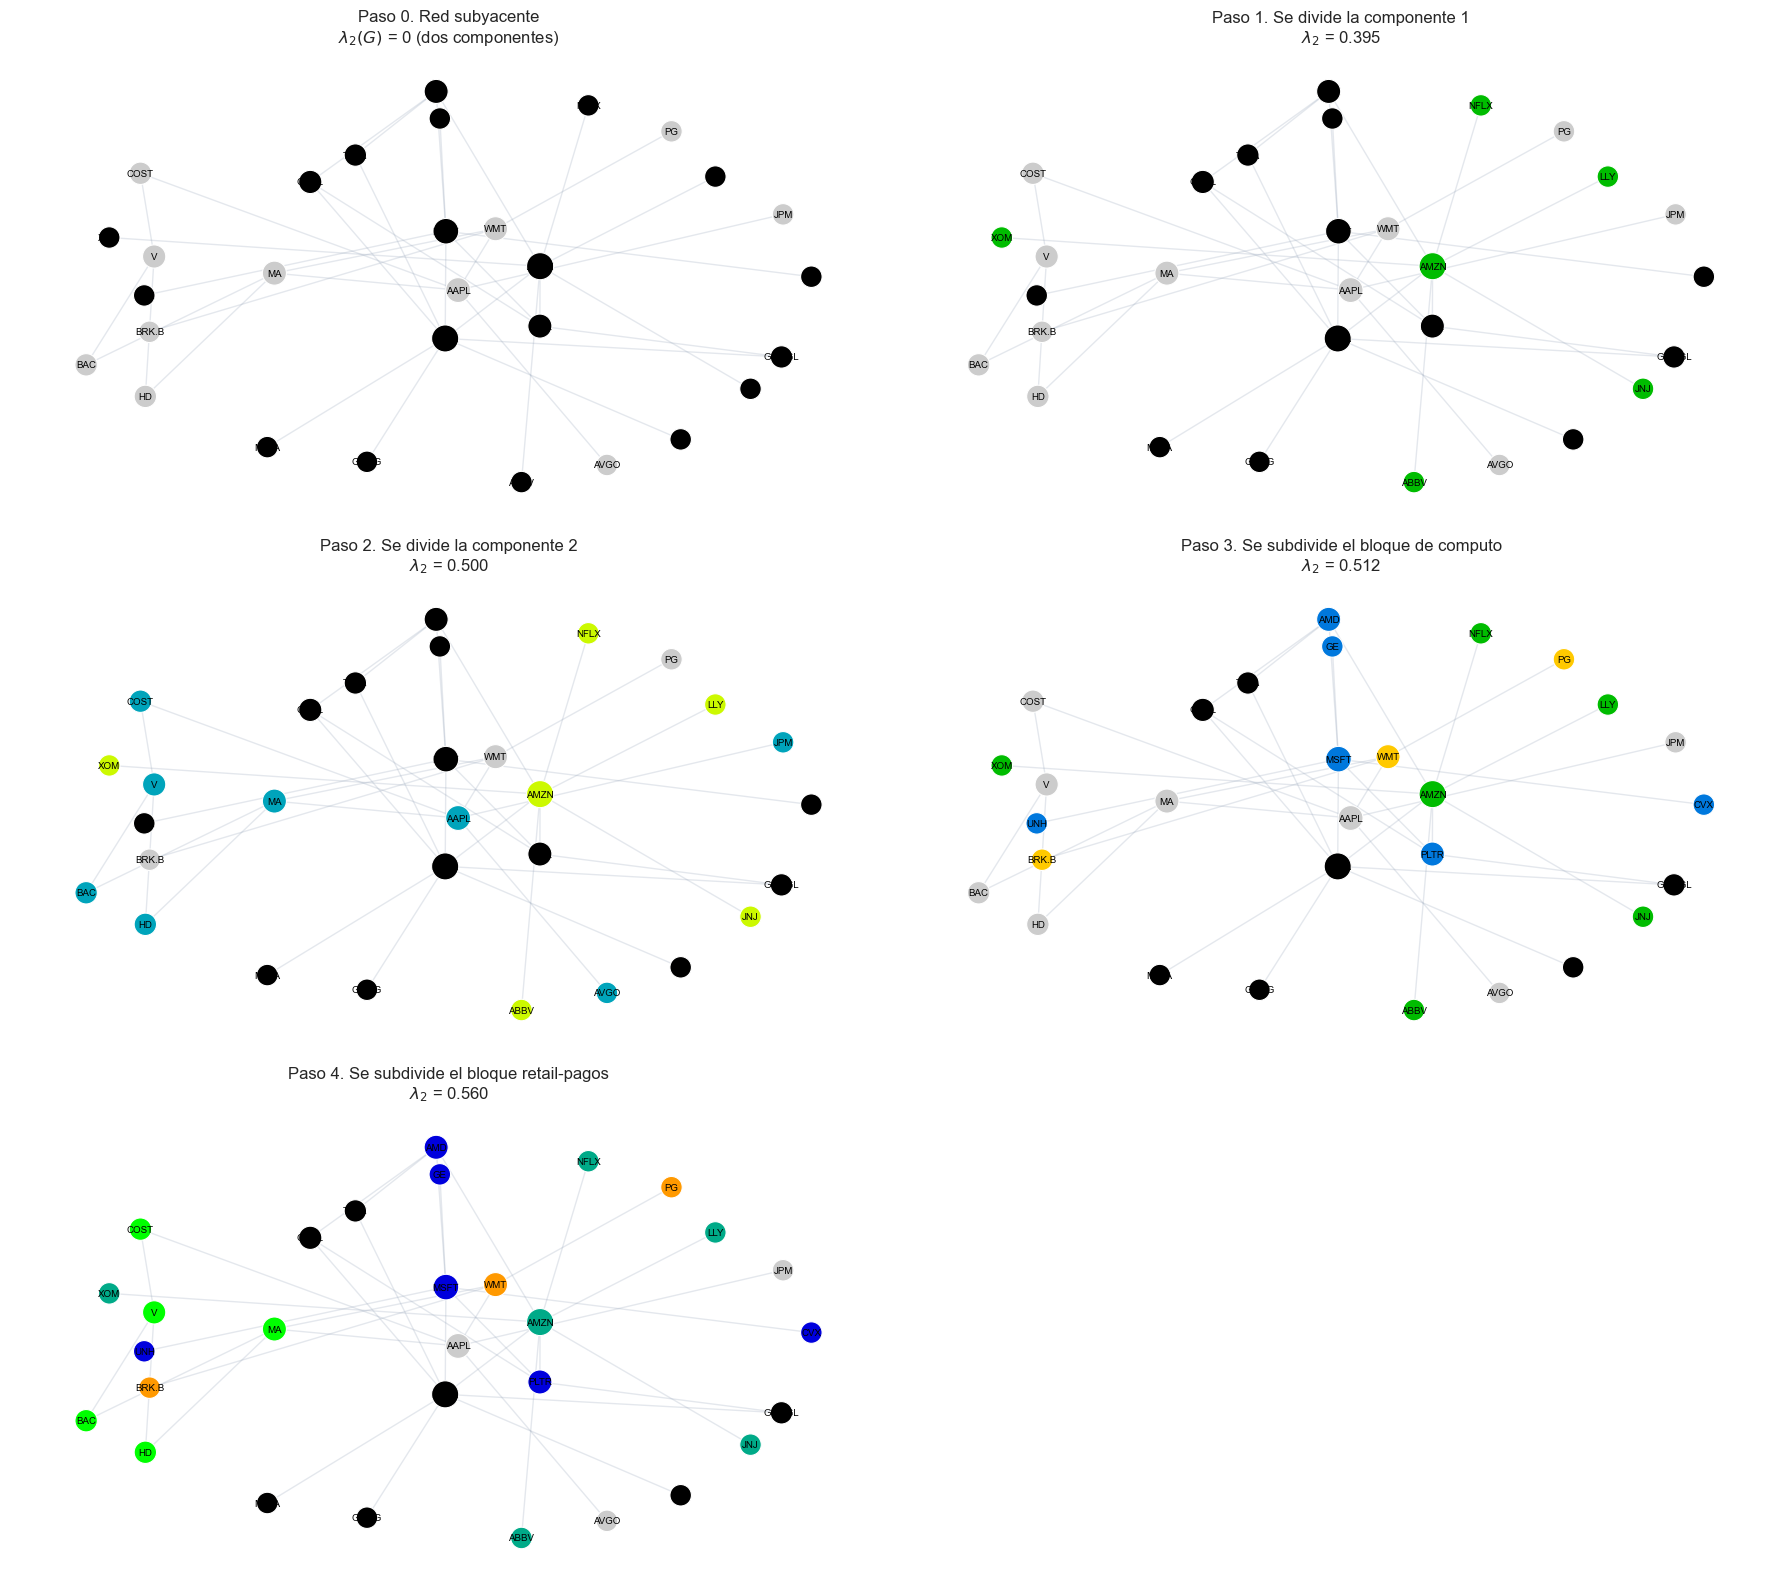

In [5]:
state_sp_after_c1 = [set(part) for part in report_sp_c1["groups"]] + [set(componentes_sp[1])]
state_sp_after_c2 = coarse_partition_sp
state_sp_after_c1_big = []
for part in report_sp_c1["groups"]:
    if set(part) == set(sp_c1_big):
        state_sp_after_c1_big.extend([set(child) for child in report_sp_c1_big["groups"]])
    else:
        state_sp_after_c1_big.append(set(part))
state_sp_after_c1_big.extend([set(part) for part in report_sp_c2["groups"]])

states_sp = [
    {
        "title": "Paso 0. Red subyacente\n$\lambda_2(G)$ = 0 (dos componentes)",
        "groups": componentes_sp,
    },
    {
        "title": f"Paso 1. Se divide la componente 1\n$\lambda_2$ = {report_sp_c1['lambda2']:.3f}",
        "groups": state_sp_after_c1,
    },
    {
        "title": f"Paso 2. Se divide la componente 2\n$\lambda_2$ = {report_sp_c2['lambda2']:.3f}",
        "groups": state_sp_after_c2,
    },
    {
        "title": f"Paso 3. Se subdivide el bloque de computo\n$\lambda_2$ = {report_sp_c1_big['lambda2']:.3f}",
        "groups": state_sp_after_c1_big,
    },
    {
        "title": f"Paso 4. Se subdivide el bloque retail-pagos\n$\lambda_2$ = {report_sp_c2_big['lambda2']:.3f}",
        "groups": refined_partition_sp,
    },
]

plot_partition_sequence(G_sp, labels_sp, states_sp, pos=pos_sp, ncols=2, figsize=(18, 16))

## 2. Comparacion con modularidad

En la notebook de modularidad se habia trabajado sobre la componente principal y aparecian 5 comunidades 
Aqui agrego dos comparaciones:

- contra greedy_modularity_communities en la red completa no dirigida
- contra la de la actividad anterior

,grafo,metodo,grupos,Q
0,SP500 completo,greedy_modularity_communities,4,0.5453
1,SP500 completo,espectral laplaciano (4 grupos),4,0.5307
2,SP500 completo,espectral laplaciano refinado (6 grupos),6,0.4865
3,SP500 componente principal,greedy_modularity_communities,5,0.3715


,grupo,nodos,aristas_internas,densidad,lambda_2,miembros
0,1,11,13,0.2364,0.4998,"AAPL, AVGO, BAC, BRK.B, COST, HD, JPM, MA, PG, V, WMT"
1,2,9,10,0.2778,0.7260,"AMD, GOOG, GOOGL, META, MU, NVDA, ORCL, PLTR, TSLA"
2,3,6,5,0.3333,1.0000,"ABBV, AMZN, JNJ, LLY, NFLX, XOM"
3,4,4,3,0.5000,1.0000,"CVX, GE, MSFT, UNH"


,grupo,nodos,aristas_internas,densidad,lambda_2,miembros
0,1,6,5,0.3333,1.0,"ABBV, AMZN, JNJ, LLY, NFLX, XOM"
1,2,4,3,0.5000,1.0,"GOOG, META, MU, NVDA"
2,3,4,3,0.5000,1.0,"CVX, GE, MSFT, UNH"
3,4,3,2,0.6667,1.0,"GOOGL, ORCL, PLTR"
4,5,2,1,1.0000,2.0,"AMD, TSLA"


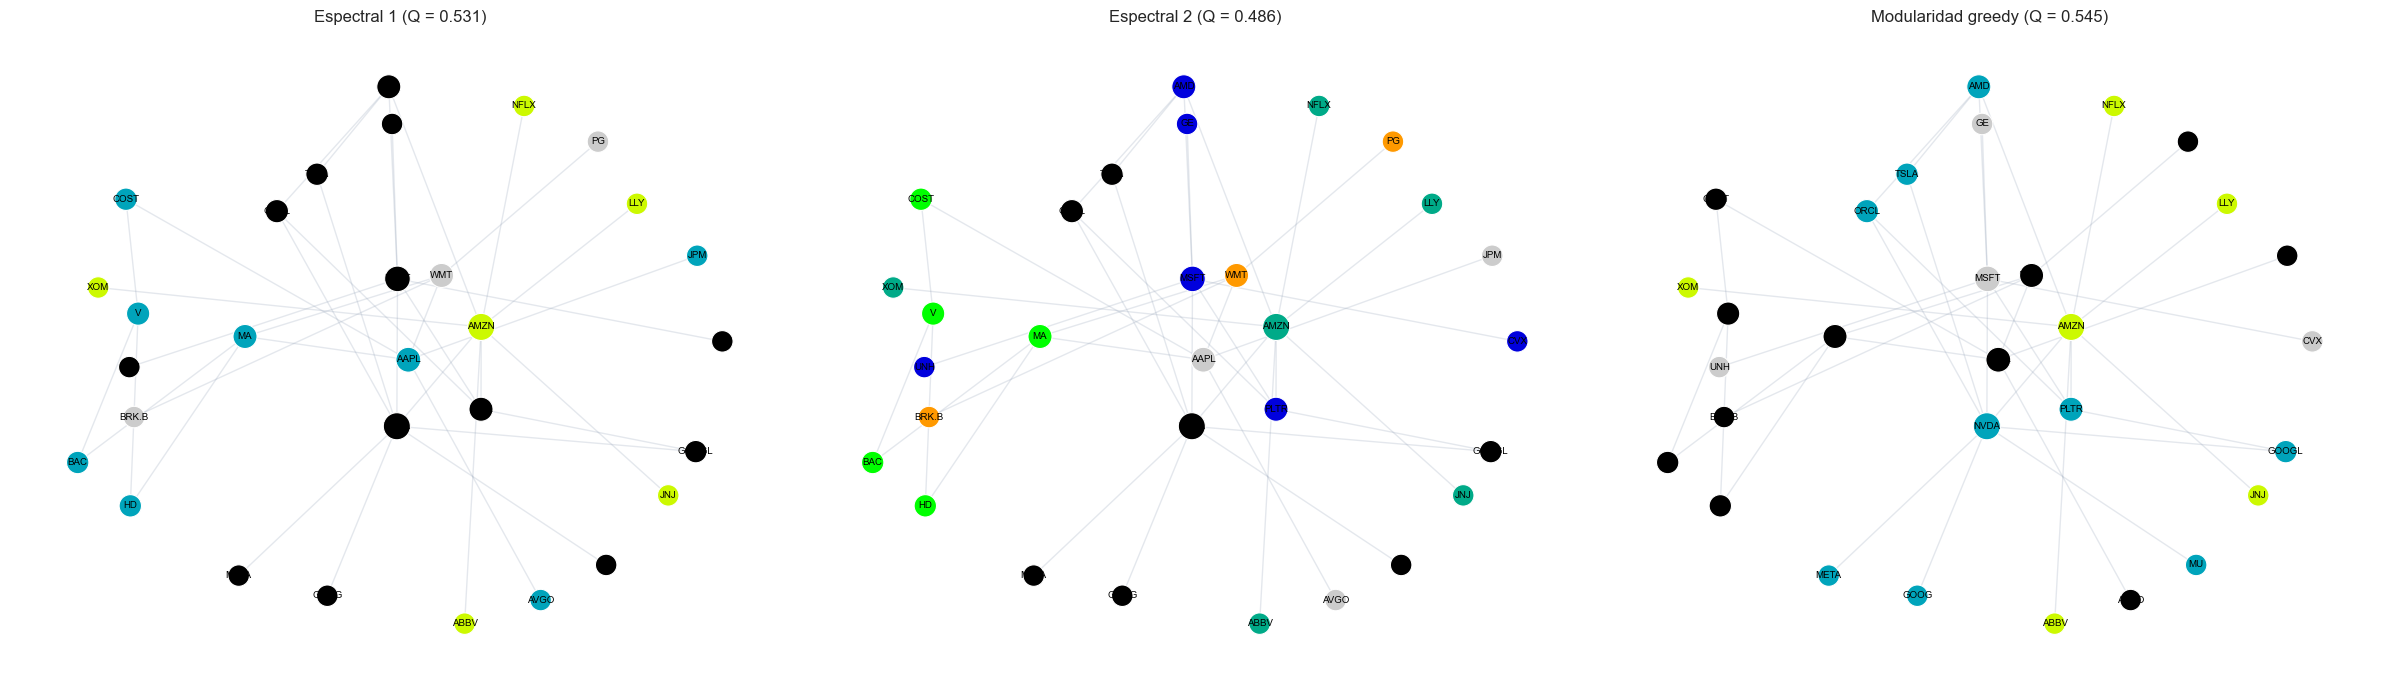

In [6]:
comunidades_mod_full_sp = sorted(list(greedy_modularity_communities(G_sp)), key=len, reverse=True)
q_spectral4_sp = nx.algorithms.community.modularity(G_sp, coarse_partition_sp)
q_spectral6_sp = nx.algorithms.community.modularity(G_sp, refined_partition_sp)
q_mod_full_sp = nx.algorithms.community.modularity(G_sp, comunidades_mod_full_sp)

G_sp_main = G_sp.subgraph(componentes_sp[0]).copy()
labels_sp_main = get_display_labels(G_sp_main)
comunidades_mod_main_sp = sorted(list(greedy_modularity_communities(G_sp_main)), key=len, reverse=True)
q_mod_main_sp = nx.algorithms.community.modularity(G_sp_main, comunidades_mod_main_sp)

comparacion_sp = comparison_table(
    [
        {
            "grafo": "SP500 completo",
            "metodo": "greedy_modularity_communities",
            "grupos": len(comunidades_mod_full_sp),
            "Q": round(q_mod_full_sp, 4),
        },
        {
            "grafo": "SP500 completo",
            "metodo": "espectral laplaciano (4 grupos)",
            "grupos": len(coarse_partition_sp),
            "Q": round(q_spectral4_sp, 4),
        },
        {
            "grafo": "SP500 completo",
            "metodo": "espectral laplaciano refinado (6 grupos)",
            "grupos": len(refined_partition_sp),
            "Q": round(q_spectral6_sp, 4),
        },
        {
            "grafo": "SP500 componente principal",
            "metodo": "greedy_modularity_communities",
            "grupos": len(comunidades_mod_main_sp),
            "Q": round(q_mod_main_sp, 4),
        },
    ]
)

display(comparacion_sp)
display(partition_summary(G_sp, comunidades_mod_full_sp, labels_sp))
display(partition_summary(G_sp_main, comunidades_mod_main_sp, labels_sp_main))

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
draw_partition(
    axes[0],
    G_sp,
    coarse_partition_sp,
    labels_sp,
    title=f"Espectral 1 (Q = {q_spectral4_sp:.3f})",
    pos=pos_sp,
)
draw_partition(
    axes[1],
    G_sp,
    refined_partition_sp,
    labels_sp,
    title=f"Espectral 2 (Q = {q_spectral6_sp:.3f})",
    pos=pos_sp,
)
draw_partition(
    axes[2],
    G_sp,
    comunidades_mod_full_sp,
    labels_sp,
    title=f"Modularidad greedy (Q = {q_mod_full_sp:.3f})",
    pos=pos_sp,
)
plt.tight_layout()
plt.show()

<!-- interpretacion-sp500: comparacion-modularidad -->
### Lectura específica de la comparación con modularidad

La modularidad greedy sobre la red completa produce 4 grupos y obtiene $Q\approx0.5453$. La partición espectral gruesa también tiene 4 grupos y queda cerca, con $Q\approx0.5307$. La refinada tiene 6 grupos, pero baja a $Q\approx0.4865$.

Esto sugiere que la refinación espectral agrega detalle interpretativo, pero no necesariamente mejora la separación comunitaria global. Económicamente, tiene sentido: separar **NVDA-GOOG-GOOGL-META-MU-ORCL-TSLA** de **MSFT-CVX-GE-UNH-AMD-PLTR** explica dos subfrentes, pero también rompe un bloque tecnológico/enterprise que modularidad prefiere conservar parcialmente.

La comunidad greedy más clara es **AAPL-AVGO-BAC-BRK.B-COST-HD-JPM-MA-PG-V-WMT**: mezcla retail, pagos, banca y consumo. No es un sector único, sino una red de relaciones comerciales alrededor de consumo y transacciones.

## Conclusión

- Las particiones espectrales tienen sentido como bloques de dependencia alrededor de hubs. En esta minired, el algoritmo no descubre “sectores” puros; descubre estructuras como satélites de AMZN, plataformas alrededor de NVDA, y retail/pagos alrededor de AAPL-WMT-V-MA.
- Para describir comunidades económicas compactas prefiero greedy modularity: en la red completa obtiene $Q\approx0.5453$, ligeramente por encima de la partición espectral gruesa ($Q\approx0.5307$) y por encima de la espectral refinada ($Q\approx0.4865$).
- La partición espectral refinada sigue siendo útil porque explica el proceso de separación: muestra qué bloques están colgados de un hub y cuándo una subdivisión adicional deja de ser una comunidad robusta para convertirse en una hoja demasiado pequeña.
- En resumen: modularidad resume mejor comunidades cerradas; el espectral explica mejor la geometría de dependencia y el papel de los hubs.

# Degree-corrected SBM

En esta sección se agrega un **modelo de bloques estocásticos corregido por grado** (*degree-corrected stochastic block model*, DC-SBM) para comparar dos particiones ya propuestas en la notebook:

1. la partición obtenida por **modularidad greedy**, guardada como `comunidades_mod_full_sp`;
2. la partición obtenida por **agrupamiento espectral grueso**, guardada como `coarse_partition_sp`.

La idea no es volver a buscar comunidades desde cero. Aquí se toma cada partición $g$ como una hipótesis candidata y se evalúa qué tan verosímil es bajo el modelo corregido por grado.

En esta minired S&P500, los nodos son empresas y las aristas representan relaciones proveedor-cliente en la red no dirigida subyacente. Entonces, una comunidad no significa sector oficial del índice, sino bloque de dependencia dentro de esta red: por ejemplo, hubs de infraestructura tecnológica, clientes cloud, retail-pagos o empresas periféricas conectadas por un proveedor central.

El modelo separa dos efectos:

- $c_i$: propensión de grado de la empresa $i$;
- $\omega_{rs}$: intensidad relativa de conexión entre los grupos $r$ y $s$.

Para una red no dirigida con matriz de adyacencia $A=(A_{ij})$, se usa la formulación de Poisson:

$$
A_{ij}\sim \operatorname{Poisson}
\left(
\omega_{g_i g_j}\frac{c_i c_j}{2m}
\right).
$$

Aquí $A_{ij}$ se interpreta como conteo/peso de relación. Como esta red no tiene pesos explícitos, cada arista observada se toma con peso $1$.

## Notación usada

Para una partición fija $g=(g_1,\ldots,g_n)$:

$$
k_i=\sum_j A_{ij}
$$

es el grado ponderado del nodo $i$. El estimador de máxima verosimilitud del parámetro de grado es

$$
\hat c_i=k_i.
$$

La masa de grado del grupo $r$ es

$$
\kappa_r=\sum_i \delta_{g_i r}k_i.
$$

El número ponderado de aristas dirigidas de grupo $r$ a grupo $s$ es

$$
m_{rs}
=
\sum_{ij}
\delta_{g_i r}\delta_{g_j s}A_{ij}.
$$

Como la red es no dirigida, $m_{rs}=m_{sr}$, pero $\kappa_r$ y $\kappa_s$ no tienen por qué ser iguales.

El estimador perfilado de la matriz de interacción comunitaria es

$$
\hat\omega_{rs}
=
\frac{2m\,m_{rs}}{\kappa_r\kappa_s}.
$$

Finalmente, la log-verosimilitud perfilada, salvo constantes que no dependen de $g$, es

$$
L(g)
=
\frac{1}{2}
\sum_{rs}
m_{rs}
\log\left(
\frac{m_{rs}}{\kappa_r\kappa_s}
\right).
$$

Como las constantes son las mismas para las dos particiones sobre la misma red, esta cantidad sirve para comparar cuál partición es más compatible con el DC-SBM.

## Pseudocódigo

```text
Entrada:
    G = red no dirigida subyacente de relaciones proveedor-cliente
    particiones = {
        "modularidad": comunidades_mod_full_sp,
        "espectral_grueso": coarse_partition_sp
    }

Para cada partición g:
    1. Calcular k_i = grado del nodo i.
    2. Calcular kappa_r = suma de k_i dentro del grupo r.
    3. Calcular m_rs = conteo observado entre grupos r y s.
       - Si una arista no dirigida queda dentro del mismo grupo, cuenta dos veces en m_rr.
       - Si una arista conecta grupos distintos, cuenta una vez en m_rs y una vez en m_sr.
    4. Estimar omega_hat_rs = 2m m_rs / (kappa_r kappa_s).
    5. Evaluar L(g) = 1/2 sum_rs m_rs log(m_rs / (kappa_r kappa_s)).
    6. Guardar tablas y visualizaciones.

Salida:
    Comparación entre partición de modularidad y partición espectral gruesa.
```

In [7]:
def normalize_partition(communities):
    """
    Convierte una lista de comunidades en una lista ordenada de conjuntos.

    La ordenación por tamaño descendente hace que las tablas sean más legibles.
    No cambia la partición matemática; solo cambia el nombre visual de los grupos.
    """
    return sorted([set(c) for c in communities], key=lambda c: (-len(c), sorted(map(str, c))))


def partition_to_lookup(communities):
    """
    Construye la asignación g_i.

    Devuelve:
        lookup[node] = r

    donde r es el índice entero del grupo al que pertenece el nodo.
    """
    lookup = {}
    for r, community in enumerate(communities):
        for node in community:
            lookup[node] = r
    return lookup


def safe_weight(edge_data, weight="weight"):
    """
    Extrae el peso de una arista.

    Si weight=None, se interpreta cada arista como peso 1.
    Si el atributo no existe, también se usa peso 1.
    """
    if weight is None:
        return 1.0
    return float(edge_data.get(weight, 1.0))


def compute_dcsbm_statistics(G, communities, partition_name, labels=None, weight="weight"):
    """
    Calcula los objetos del degree-corrected SBM para una partición fija g.

    Parámetros
    ----------
    G : networkx.Graph
        Red no dirigida. Puede ser ponderada.
    communities : list[set]
        Partición candidata de los nodos.
    partition_name : str
        Nombre de la partición para reportes.
    labels : dict, optional
        Diccionario node -> etiqueta visible.
    weight : str or None
        Atributo de peso. Si None, se usa una red no ponderada.

    Devuelve
    --------
    stats : dict
        Diccionario con:
        - k_i: grados ponderados.
        - kappa_r: masa de grado por grupo.
        - m_rs: matriz de pesos observados entre grupos.
        - omega_hat_rs: estimador perfilado de Omega.
        - L_profile: log-verosimilitud perfilada sin constantes.
    """
    communities = normalize_partition(communities)
    lookup = partition_to_lookup(communities)
    nodes = list(G.nodes())
    q = len(communities)

    missing_nodes = sorted(set(nodes) - set(lookup), key=str)
    extra_nodes = sorted(set(lookup) - set(nodes), key=str)
    if missing_nodes or extra_nodes:
        raise ValueError(
            "La partición no coincide con los nodos de G. "
            f"missing_nodes={missing_nodes}, extra_nodes={extra_nodes}"
        )

    # k_i = grado ponderado del nodo i
    k_i = {node: float(G.degree(node, weight=weight)) for node in nodes}

    # m = peso total no dirigido. En NetworkX, G.size(weight) suma cada arista una vez.
    m = float(G.size(weight=weight))
    if m <= 0:
        raise ValueError("La red no tiene peso total positivo.")

    # kappa_r = suma de grados ponderados dentro de cada grupo r.
    kappa_r = np.zeros(q, dtype=float)
    for node, degree in k_i.items():
        r = lookup[node]
        kappa_r[r] += degree

    # m_rs = sum_ij delta_{g_i r} delta_{g_j s} A_ij.
    #
    # En una red no dirigida sin lazos:
    # - una arista interna u--v dentro de r aporta A_uv + A_vu = 2w a m_rr;
    # - una arista cruzada entre r y s aporta w a m_rs y w a m_sr.
    m_rs = np.zeros((q, q), dtype=float)

    for u, v, edge_data in G.edges(data=True):
        w = safe_weight(edge_data, weight=weight)
        r = lookup[u]
        s = lookup[v]

        if u == v:
            # Caso raro: lazo. En una matriz de adyacencia no dirigida, se trata como contribución diagonal.
            m_rs[r, s] += 2.0 * w
        elif r == s:
            m_rs[r, r] += 2.0 * w
        else:
            m_rs[r, s] += w
            m_rs[s, r] += w

    # Verificación: sum_rs m_rs debe ser 2m.
    directed_total = float(m_rs.sum())
    if not np.isclose(directed_total, 2.0 * m):
        raise ArithmeticError(
            f"Inconsistencia en conteos: sum_rs m_rs={directed_total}, pero 2m={2.0*m}."
        )

    denominator = np.outer(kappa_r, kappa_r)

    with np.errstate(divide="ignore", invalid="ignore"):
        omega_hat_rs = (2.0 * m * m_rs) / denominator

    # Convención: si m_rs=0, entonces m_rs log(m_rs/(kappa_r kappa_s)) = 0.
    with np.errstate(divide="ignore", invalid="ignore"):
        profile_terms = np.where(
            m_rs > 0,
            0.5 * m_rs * np.log(m_rs / denominator),
            0.0,
        )

    L_profile = float(np.nansum(profile_terms))

    # Versión equivalente que incluye el factor 2m dentro del logaritmo.
    # Difiere por una constante común entre particiones de la misma red.
    with np.errstate(divide="ignore", invalid="ignore"):
        profile_terms_with_2m = np.where(
            m_rs > 0,
            0.5 * m_rs * np.log((2.0 * m * m_rs) / denominator),
            0.0,
        )
    L_profile_with_2m = float(np.nansum(profile_terms_with_2m))

    group_names = [f"G{r+1}" for r in range(q)]

    return {
        "partition_name": partition_name,
        "communities": communities,
        "lookup": lookup,
        "nodes": nodes,
        "labels": labels if labels is not None else {node: str(node) for node in nodes},
        "q": q,
        "m": m,
        "k_i": k_i,
        "kappa_r": kappa_r,
        "m_rs": m_rs,
        "omega_hat_rs": omega_hat_rs,
        "profile_terms": profile_terms,
        "L_profile": L_profile,
        "L_profile_with_2m": L_profile_with_2m,
        "group_names": group_names,
        "internal_directed_weight": float(np.trace(m_rs)),
        "external_directed_weight": float(m_rs.sum() - np.trace(m_rs)),
        "internal_share": float(np.trace(m_rs) / m_rs.sum()),
    }


def matrix_to_dataframe(matrix, group_names):
    """Convierte una matriz q x q en DataFrame con nombres de grupo."""
    return pd.DataFrame(matrix, index=group_names, columns=group_names)


def dcsbm_group_table(stats):
    """
    Tabla por grupo:
    - nodos;
    - kappa_r;
    - peso interno dirigido m_rr;
    - miembros.
    """
    rows = []
    labels = stats["labels"]

    for r, community in enumerate(stats["communities"]):
        rows.append(
            {
                "particion": stats["partition_name"],
                "grupo": f"G{r+1}",
                "nodos": len(community),
                "kappa_r": stats["kappa_r"][r],
                "m_rr": stats["m_rs"][r, r],
                "omega_hat_rr": stats["omega_hat_rs"][r, r],
                "miembros": ", ".join(sorted(labels[node] for node in community)),
            }
        )

    return pd.DataFrame(rows)


def dcsbm_comparison_table(stats_list):
    """Tabla comparativa entre particiones candidatas."""
    rows = []
    for stats in stats_list:
        rows.append(
            {
                "particion": stats["partition_name"],
                "q": stats["q"],
                "m": stats["m"],
                "sum_kappa_r": stats["kappa_r"].sum(),
                "sum_m_rs": stats["m_rs"].sum(),
                "peso_dirigido_interno": stats["internal_directed_weight"],
                "peso_dirigido_externo": stats["external_directed_weight"],
                "proporcion_interna": stats["internal_share"],
                "L_perfilada_sin_constantes": stats["L_profile"],
                "L_perfilada_con_2m": stats["L_profile_with_2m"],
            }
        )
    return pd.DataFrame(rows).sort_values("L_perfilada_sin_constantes", ascending=False).reset_index(drop=True)


def _matrix_color_limits(matrices):
    """Devuelve limites robustos para usar una misma escala de color."""
    finite_values = []
    for matrix in matrices:
        values = np.asarray(matrix, dtype=float)
        values = values[np.isfinite(values)]
        if values.size:
            finite_values.append(values)

    if not finite_values:
        return 0, 1

    values = np.concatenate(finite_values)
    vmin = min(0, values.min()) if values.min() >= 0 else values.min()
    vmax = values.max()
    if np.isclose(vmin, vmax):
        vmax = vmin + 1
    return vmin, vmax


def _format_matrix_value(value):
    if not np.isfinite(value):
        return "nan"
    abs_value = abs(value)
    if abs_value >= 100:
        return f"{value:.0f}"
    if abs_value >= 10:
        return f"{value:.1f}"
    if abs_value >= 1:
        return f"{value:.2f}"
    if abs_value == 0:
        return "0"
    return f"{value:.3f}"


def _annotated_heatmap(ax, matrix, group_names, title, cmap, norm, cbar_label=None):
    matrix = np.asarray(matrix, dtype=float)
    cmap = plt.get_cmap(cmap).copy()
    cmap.set_bad("#f2f4f8")

    image = ax.imshow(np.ma.masked_invalid(matrix), cmap=cmap, norm=norm, interpolation="nearest")
    ax.set_title(title, fontweight="bold", pad=12)
    ax.set_xticks(range(len(group_names)))
    ax.set_yticks(range(len(group_names)))
    ax.set_xticklabels(group_names, rotation=35, ha="right", rotation_mode="anchor")
    ax.set_yticklabels(group_names)
    ax.set_xlabel("Grupo destino s")
    ax.set_ylabel("Grupo origen r")

    ax.grid(False)
    ax.set_xticks(np.arange(-0.5, matrix.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, matrix.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.6)
    ax.tick_params(which="minor", bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    color_span = norm.vmax - norm.vmin
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix[i, j]
            if not np.isfinite(value):
                text_color = "#263238"
            else:
                intensity = 0 if color_span == 0 else (value - norm.vmin) / color_span
                text_color = "white" if intensity > 0.58 else "#263238"
            ax.text(j, i, _format_matrix_value(value), ha="center", va="center", color=text_color, fontsize=9, fontweight="semibold")

    cbar = ax.figure.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    if cbar_label:
        cbar.set_label(cbar_label)
    return image


def plot_dcsbm_matrices(stats_list):
    """
    Visualiza, para cada partición, las matrices m_rs y omega_hat_rs.

    m_rs muestra conteos/pesos observados entre grupos.
    omega_hat_rs muestra intensidad relativa estimada después de corregir por grado.
    """
    if not stats_list:
        return

    nrows = len(stats_list)
    fig, axes = plt.subplots(nrows, 2, figsize=(15, 4.8 * nrows), squeeze=False, constrained_layout=True)

    m_norm = Normalize(*_matrix_color_limits([stats["m_rs"] for stats in stats_list]))
    omega_norm = Normalize(*_matrix_color_limits([stats["omega_hat_rs"] for stats in stats_list]))

    for row, stats in enumerate(stats_list):
        group_names = stats["group_names"]

        _annotated_heatmap(
            axes[row, 0],
            stats["m_rs"],
            group_names,
            f"{stats['partition_name']}\n" + r"$m_{rs}$: pesos observados",
            cmap="YlGnBu",
            norm=m_norm,
            cbar_label="peso observado",
        )
        _annotated_heatmap(
            axes[row, 1],
            stats["omega_hat_rs"],
            group_names,
            f"{stats['partition_name']}\n" + r"$\hat{\omega}_{rs}$: intensidad corregida por grado",
            cmap="magma",
            norm=omega_norm,
            cbar_label="intensidad",
        )

    plt.show()


def plot_dcsbm_scores(stats_list):
    """Grafica la log-verosimilitud perfilada para las particiones comparadas."""
    if not stats_list:
        return

    names = np.array([stats["partition_name"] for stats in stats_list])
    scores = np.array([stats["L_profile"] for stats in stats_list], dtype=float)
    order = np.argsort(scores)[::-1]
    names = names[order]
    scores = scores[order]

    score_norm = Normalize(*_matrix_color_limits([scores]))
    colors = plt.get_cmap("viridis")(score_norm(scores))

    fig, ax = plt.subplots(figsize=(10, max(4.5, 0.72 * len(names))))
    bars = ax.barh(names, scores, color=colors, edgecolor="#263238", linewidth=0.8)
    ax.invert_yaxis()
    ax.axvline(0, color="#90a4ae", linewidth=1)
    ax.set_xlabel(r"$L(g)$ sin constantes")
    ax.set_title("Comparación DC-SBM de particiones candidatas", fontweight="bold", pad=12)
    ax.grid(axis="x", color="#d0d7de", linewidth=0.8, alpha=0.7)

    best_score = scores[0]
    labels = [f"{score:,.2f}  ({score - best_score:+.2f})" for score in scores]
    labels[0] = f"{best_score:,.2f}  (mejor)"
    ax.bar_label(bars, labels=labels, padding=5, fontsize=9)

    plt.tight_layout()
    plt.show()


def node_membership_table(stats):
    """Tabla nodo-grupo para revisar la asignación g_i."""
    labels = stats["labels"]
    rows = []
    for node in stats["nodes"]:
        rows.append(
            {
                "particion": stats["partition_name"],
                "nodo": labels[node],
                "grupo": f"G{stats['lookup'][node]+1}",
                "k_i": stats["k_i"][node],
            }
        )
    return pd.DataFrame(rows).sort_values(["grupo", "k_i", "nodo"], ascending=[True, False, True]).reset_index(drop=True)

## Evaluación de las dos particiones

Se evalúan las dos particiones ya construidas arriba: modularidad greedy sobre la red completa y agrupamiento espectral grueso. Ambas tienen $q=6$ grupos, así que la comparación bajo DC-SBM es directa.

La pregunta cambia respecto a la sección anterior. Ya no pregunto solamente si hay muchas aristas internas, sino si los enlaces proveedor-cliente son plausibles bajo un modelo que corrige por el grado de cada empresa. Esto importa porque empresas como NVDA, AMZN, MSFT, AAPL o WMT pueden actuar como hubs: sin corrección por grado, esos hubs pueden dominar cualquier partición solo por tener muchas relaciones.

In [8]:
partitions_for_dcsbm = {
    "Modularidad greedy": comunidades_mod_full_sp,
    "Agrupamiento espectral grueso": coarse_partition_sp,
}

q_values = {name: len(normalize_partition(partition)) for name, partition in partitions_for_dcsbm.items()}
print("Numero de grupos por particion:", q_values)

if len(set(q_values.values())) != 1:
    raise ValueError(
        "Las particiones no tienen el mismo numero de grupos. "
        "Para una comparacion directa, usa particiones con el mismo q."
    )

dcsbm_stats_sp = [
    compute_dcsbm_statistics(
        G_sp,
        communities=partition,
        partition_name=name,
        labels=labels_sp,
        weight="weight",
    )
    for name, partition in partitions_for_dcsbm.items()
]

comparacion_dcsbm_sp = dcsbm_comparison_table(dcsbm_stats_sp)
display(comparacion_dcsbm_sp)

Numero de grupos por particion: {'Modularidad greedy': 4, 'Agrupamiento espectral grueso': 4}


,particion,q,m,sum_kappa_r,sum_m_rs,peso_dirigido_interno,peso_dirigido_externo,proporcion_interna,L_perfilada_sin_constantes,L_perfilada_con_2m
0,Modularidad greedy,4,37.0,74.0,74.0,62.0,12.0,0.837838,-126.747927,32.502481
1,Agrupamiento espectral grueso,4,37.0,74.0,74.0,64.0,10.0,0.864865,-128.013960,31.236448


<!-- interpretacion-sp500: evaluacion-dcsbm -->
### Lectura específica de la tabla DC-SBM

La partición de modularidad tiene $L(g)=-126.7479$ y proporción interna $0.8378$. La partición espectral gruesa tiene $L(g)=-128.0140$ y proporción interna $0.8649$.

Aunque la partición espectral gruesa tiene más peso interno dirigido ($64$ contra $62$), el DC-SBM prefiere modularidad. Esto pasa porque el modelo corrige por grado: no basta con meter más enlaces dentro de grupos; importa si esos enlaces son sorprendentes después de considerar que **NVDA, AMZN, MSFT, AAPL y WMT** son hubs.

La ventaja de modularidad es pequeña pero real: $\Delta L\approx1.266$. En cociente de verosimilitudes, eso equivale a $\exp(\Delta L)\approx3.55$. Bajo el DC-SBM, modularidad explica la red unas 3.5 veces mejor que la partición espectral gruesa, ignorando constantes comunes.

## Matrices $m_{rs}$, $\kappa_r$ y $\hat\omega_{rs}$

La matriz $m_{rs}$ dice cuánta conexión observada hay entre grupos.

La matriz $\hat\omega_{rs}$ corrige esos conteos por la masa de grado $\kappa_r\kappa_s$. Por eso puede pasar que dos grupos tengan muchos enlaces entre sí, pero una intensidad corregida no tan alta si contienen hubs con muchos enlaces.

Interpretación práctica:

- valores diagonales altos en $m_{rs}$: muchos enlaces internos;
- valores diagonales altos en $\hat\omega_{rs}$: conexión interna mayor a la esperada después de corregir por grado;
- valores fuera de la diagonal altos en $\hat\omega_{rs}$: interacción fuerte entre dos comunidades distintas;
- si $\hat\omega_{rr}$ domina la fila/columna, el grupo es asortativo: sus empresas se conectan más dentro del bloque que con el resto, incluso después de corregir por hubs.

Modularidad greedy
kappa_r


,grupo,kappa_r
0,G1,26.0
1,G2,26.0
2,G3,13.0
3,G4,9.0


m_rs


,G1,G2,G3,G4
G1,26.0,0.0,0.0,0.0
G2,0.0,20.0,3.0,3.0
G3,0.0,3.0,10.0,0.0
G4,0.0,3.0,0.0,6.0


omega_hat_rs


...

,G1,G2,G3,G4
G1,32.0,0.0,3.0,0.0
G2,0.0,18.0,0.0,2.0
G3,3.0,0.0,10.0,0.0
G4,0.0,2.0,0.0,4.0


omega_hat_rs


,G1,G2,G3,G4
G1,1.9331,0.0000,0.4879,0.0000
G2,0.0000,3.3300,0.0000,1.2333
G3,0.4879,0.0000,4.3787,0.0000
G4,0.0000,1.2333,0.0000,8.2222


Resumen por grupo


,particion,grupo,nodos,kappa_r,m_rr,omega_hat_rr,miembros
0,Agrupamiento espectral grueso,G1,13,35.0,32.0,1.9331,"AMD, CVX, GE, GOOG, GOOGL, META, MSFT, MU, NVDA, ORCL, PLTR, TSLA, UNH"
1,Agrupamiento espectral grueso,G2,8,20.0,18.0,3.3300,"AAPL, AVGO, BAC, COST, HD, JPM, MA, V"
2,Agrupamiento espectral grueso,G3,6,13.0,10.0,4.3787,"ABBV, AMZN, JNJ, LLY, NFLX, XOM"
3,Agrupamiento espectral grueso,G4,3,6.0,4.0,8.2222,"BRK.B, PG, WMT"


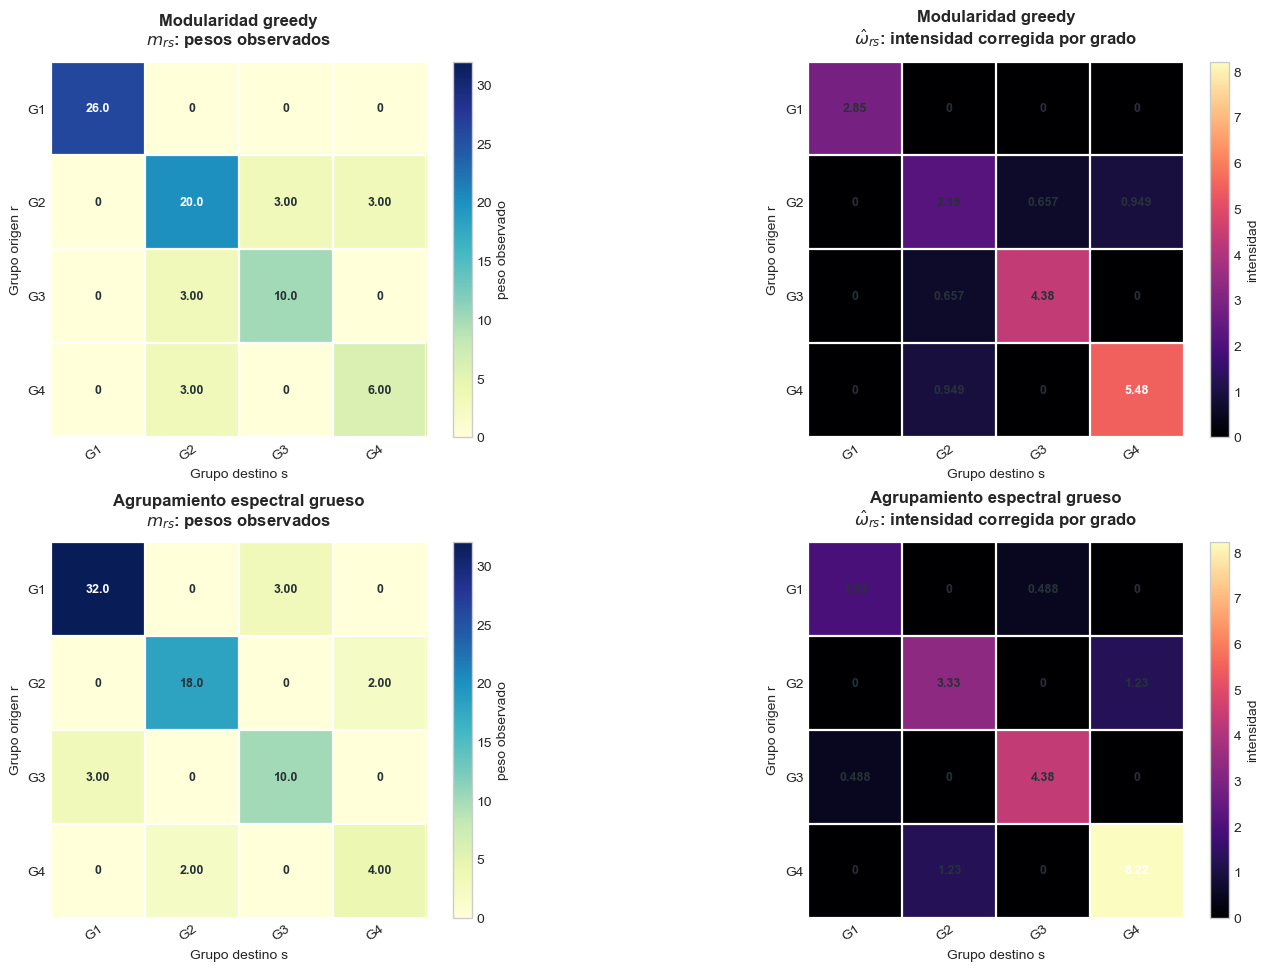

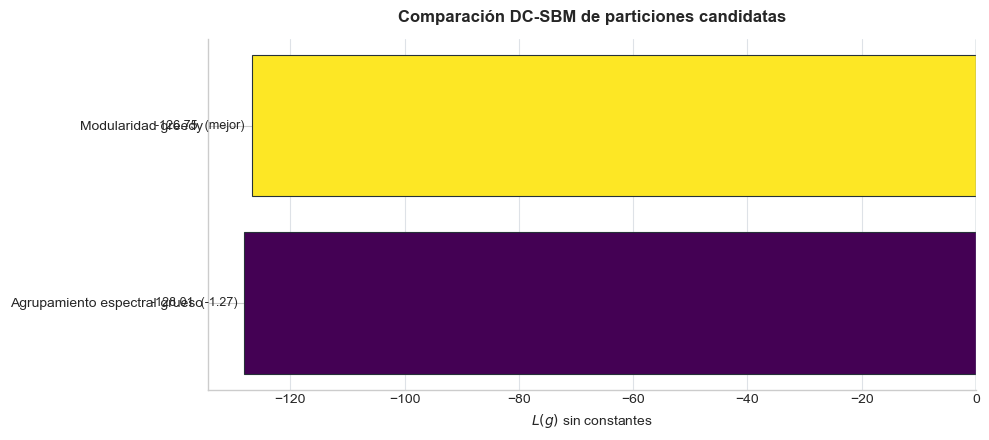

In [9]:
for stats in dcsbm_stats_sp:
    print("=" * 100)
    print(stats["partition_name"])
    print("kappa_r")
    display(pd.DataFrame({"grupo": stats["group_names"], "kappa_r": stats["kappa_r"]}))

    print("m_rs")
    display(matrix_to_dataframe(stats["m_rs"], stats["group_names"]))

    print("omega_hat_rs")
    display(matrix_to_dataframe(stats["omega_hat_rs"], stats["group_names"]).round(4))

    print("Resumen por grupo")
    display(dcsbm_group_table(stats).round({"kappa_r": 4, "m_rr": 4, "omega_hat_rr": 4}))

plot_dcsbm_matrices(dcsbm_stats_sp)
plot_dcsbm_scores(dcsbm_stats_sp)

<!-- interpretacion-sp500: matrices-dcsbm -->
### Interpretación por bloques de las matrices DC-SBM

Para **modularidad greedy**, los cuatro grupos son asortativos: sus diagonales de $\hat\omega$ son mayores que sus interacciones cruzadas principales.

- **G1** reúne **AAPL, AVGO, BAC, BRK.B, COST, HD, JPM, MA, PG, V, WMT**. Tiene $m_{11}=26$ y $\hat\omega_{11}=2.8462$. Es el bloque retail/pagos/consumo-finanzas. La ausencia de enlaces hacia otros grupos en esta minired indica que esta componente está separada del bloque tecnología-cloud.
- **G2** reúne **AMD, GOOG, GOOGL, META, MU, NVDA, ORCL, PLTR, TSLA**. Tiene $m_{22}=20$ y $\hat\omega_{22}=2.1893$. Es el bloque IA/plataformas/semiconductores: NVDA aparece como hub, y AMD, MU, ORCL, PLTR y las plataformas digitales quedan cerca por relaciones de infraestructura y demanda computacional.
- **G3** reúne **ABBV, AMZN, JNJ, LLY, NFLX, XOM**. Tiene $m_{33}=10$ y $\hat\omega_{33}=4.3787$. No es un sector homogéneo; es un bloque de satélites alrededor de AMZN. Su alta intensidad corregida aparece porque AMZN concentra varias relaciones con empresas que no se conectan mucho entre sí.
- **G4** reúne **CVX, GE, MSFT, UNH**. Tiene $m_{44}=6$ y $\hat\omega_{44}=5.4815$. Es un bloque pequeño pero intenso: MSFT conecta con CVX, GE y UNH, por eso el grupo funciona como una estrella enterprise/industrial/salud-energía.

Para **agrupamiento espectral grueso**, el grupo tecnológico grande tiene $m_{11}=32$, pero $\hat\omega_{11}=1.9331$, menor que varias diagonales de modularidad. Esa es la clave: al juntar 13 nodos con $\kappa_1=35$, el bloque tiene muchos enlaces, pero no todos son igualmente sorprendentes después de corregir por grado.

## Visualización de las particiones con score DC-SBM

La siguiente figura conserva el layout usado previamente en la notebook. El título de cada red incluye la log-verosimilitud perfilada de la partición.

Como el valor absoluto de $L(g)$ incluye constantes omitidas, lo relevante aquí es la comparación entre particiones sobre la misma red.

En esta red, la partición de modularidad debe leerse como bloques económicos compactos de relaciones proveedor-cliente. La partición espectral gruesa, en cambio, enfatiza cómo se separan ramas alrededor de hubs y cuándo una rama queda casi colgada de un nodo central.

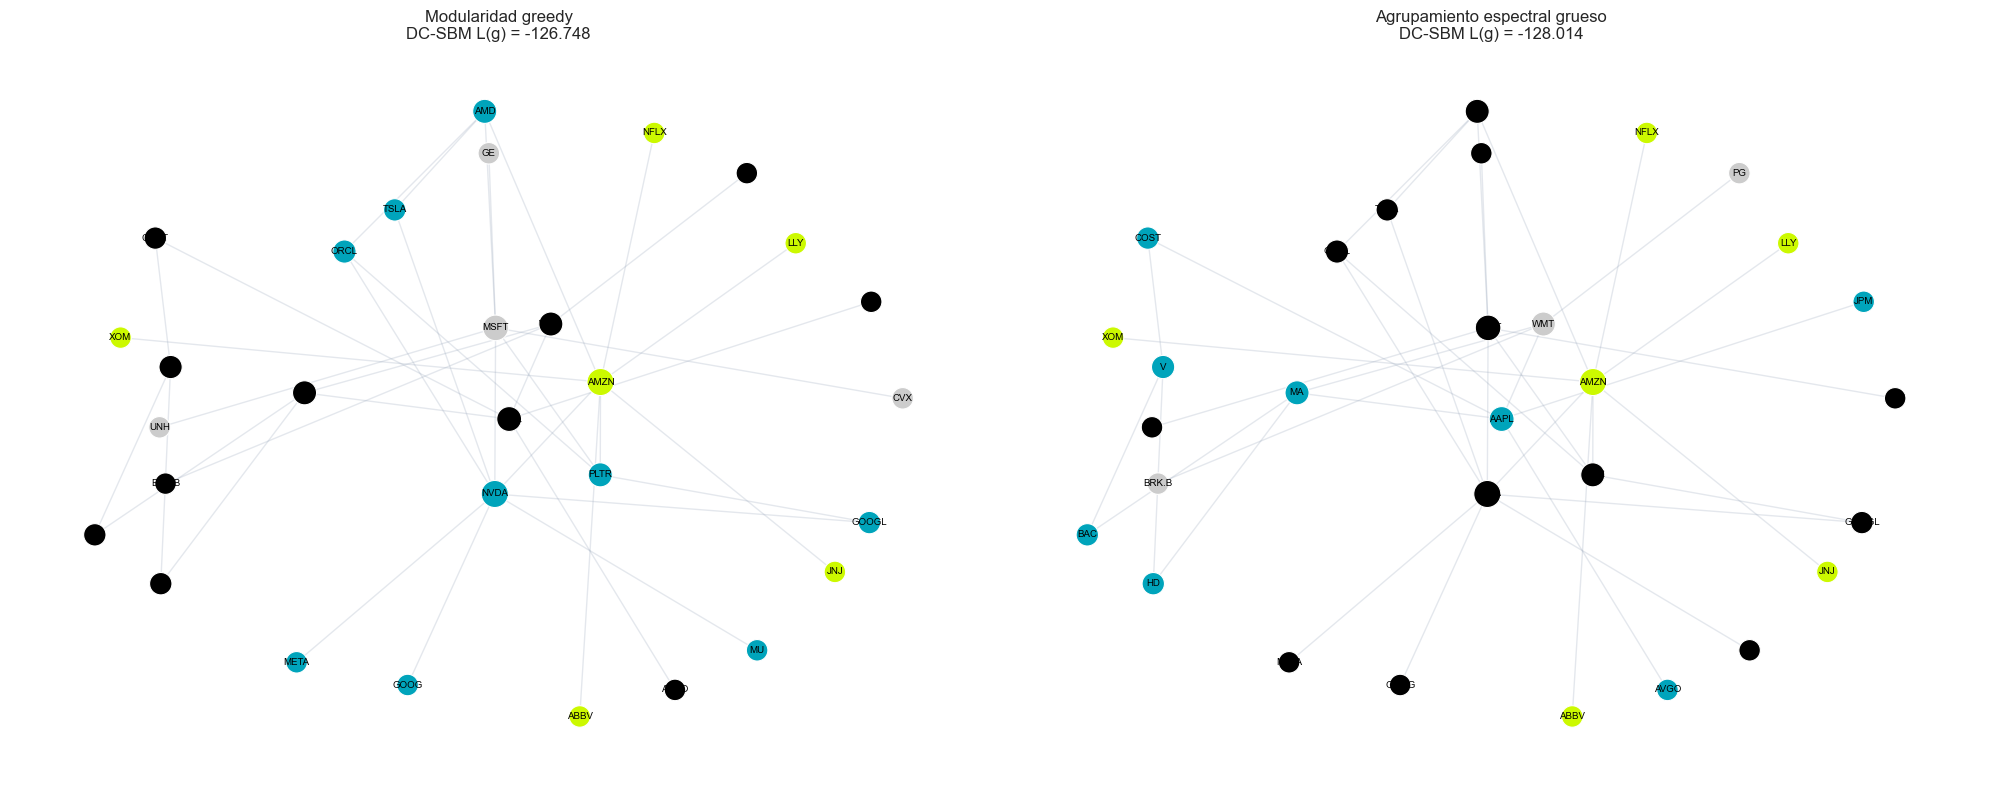

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, stats in zip(axes, dcsbm_stats_sp):
    draw_partition(
        ax,
        G_sp,
        stats["communities"],
        labels_sp,
        title=f"{stats['partition_name']}\nDC-SBM L(g) = {stats['L_profile']:.3f}",
        pos=pos_sp,
    )

plt.tight_layout()
plt.show()

<!-- interpretacion-sp500: visualizacion-particiones -->
### Lectura de la figura de particiones

En la figura de modularidad, el bloque retail/pagos aparece como una componente completa separada. Eso refleja la estructura de la minired: **AAPL, WMT, MA, V, COST, HD, JPM, BAC, PG, BRK.B y AVGO** no tienen enlaces hacia el componente de NVDA/AMZN/MSFT.

En la figura espectral gruesa, el bloque de 19 nodos se divide en un frente amplio de tecnología/enterprise y un frente AMZN-satélites. Esta lectura es útil para entender dependencia alrededor de hubs, pero el DC-SBM prefiere modularidad porque separa mejor el subgrupo **MSFT-CVX-GE-UNH**, que tiene una intensidad interna corregida muy alta.

## Revisión de asignaciones nodo-grupo

Estas tablas permiten revisar explícitamente el vector $g$. Es decir, muestran a qué grupo pertenece cada ticker bajo cada partición y cuál es su grado $k_i$.

Esta revisión es necesaria porque un grupo puede verse estadísticamente bueno pero tener una lectura económica distinta: por ejemplo, un bloque alrededor de NVDA puede mezclar semiconductores, cloud y plataformas; un bloque alrededor de AAPL puede mezclar pagos, retail y consumo. La tabla ayuda a traducir comunidades matemáticas a dependencias de negocio.

In [11]:
for stats in dcsbm_stats_sp:
    print("=" * 100)
    print(stats["partition_name"])
    display(node_membership_table(stats))

Modularidad greedy


,particion,nodo,grupo,k_i
0,Modularidad greedy,AAPL,G1,5.0
1,Modularidad greedy,MA,G1,4.0
2,Modularidad greedy,WMT,G1,4.0
3,Modularidad greedy,V,G1,3.0
4,Modularidad greedy,BAC,G1,2.0
5,Modularidad greedy,COST,G1,2.0
6,Modularidad greedy,HD,G1,2.0
7,Modularidad greedy,AVGO,G1,1.0
8,Modularidad greedy,BRK.B,G1,1.0
9,Modularidad greedy,JPM,G1,1.0


Agrupamiento espectral grueso


,particion,nodo,grupo,k_i
0,Agrupamiento espectral grueso,NVDA,G1,8.0
1,Agrupamiento espectral grueso,MSFT,G1,6.0
2,Agrupamiento espectral grueso,AMD,G1,4.0
3,Agrupamiento espectral grueso,PLTR,G1,4.0
4,Agrupamiento espectral grueso,ORCL,G1,3.0
5,Agrupamiento espectral grueso,GOOGL,G1,2.0
6,Agrupamiento espectral grueso,TSLA,G1,2.0
7,Agrupamiento espectral grueso,CVX,G1,1.0
8,Agrupamiento espectral grueso,GE,G1,1.0
9,Agrupamiento espectral grueso,GOOG,G1,1.0


<!-- interpretacion-sp500: asignaciones -->
### Lectura específica de las asignaciones

Los grados más altos son **NVDA** y **AMZN** con $k_i=8$, seguidos por **MSFT** con $k_i=6$ y **AAPL** con $k_i=5$.

- **NVDA** organiza el bloque de IA/plataformas: se conecta con MSFT, AMZN, GOOG, GOOGL, ORCL, META, TSLA y recibe relación de MU.
- **AMZN** funciona como hub transversal: se conecta con NFLX, XOM, JNJ, ABBV, PLTR, AMD y NVDA. Por eso su comunidad no es sectorial; es una vecindad de relaciones comerciales diversas.
- **MSFT** queda en un grupo pequeño con CVX, GE y UNH bajo modularidad. Esto no significa que MSFT sea “del sector industrial”; significa que, en esta minired, esas relaciones forman una estrella suficientemente intensa para separarse.
- **AAPL** queda dentro del bloque retail/pagos/consumo-finanzas, porque sus relaciones con WMT, COST, MA, JPM y AVGO lo colocan en la componente transaccional de la red.

## Interpretación

La partición con mayor $L(g)$ es la más compatible con el **degree-corrected stochastic block model** entre las dos candidatas evaluadas.

Esto no significa necesariamente que sea la mejor partición económica. Significa algo más específico:

$$
\text{mejor }L(g)
\quad\Longleftrightarrow\quad
\text{mejor ajuste estadístico bajo el DC-SBM}.
$$

La diferencia frente a modularidad es conceptual:

- la **modularidad** compara contra un modelo nulo de configuración y premia exceso de aristas internas;
- el **DC-SBM** estima explícitamente una matriz $\Omega$ de interacción entre grupos y corrige por heterogeneidad de grado usando $c_i$;
- el **agrupamiento espectral** no maximiza directamente esta verosimilitud, sino que usa la geometría de la Laplaciana para encontrar cortes estructurales.

En esta red, la corrección por grado es clave: los hubs de relaciones proveedor-cliente pueden producir muchos enlaces por su posición de mercado. El DC-SBM pregunta si, además de esa centralidad individual, hay bloques que concentran enlaces de forma sistemática.

In [12]:
winner = max(dcsbm_stats_sp, key=lambda stats: stats["L_profile"])
loser = min(dcsbm_stats_sp, key=lambda stats: stats["L_profile"])
delta_L = winner["L_profile"] - loser["L_profile"]

print("Mejor particion bajo DC-SBM:")
print(f"  {winner['partition_name']}")
print(f"  L(g) = {winner['L_profile']:.6f}")
print()
print("Comparacion:")
print(f"  Diferencia de log-verosimilitud perfilada: Delta L = {delta_L:.6f}")
print()
print(
    "Lectura: si Delta L > 0, la particion ganadora concentra mejor los patrones "
    "de conexion entre grupos despues de corregir por los grados ponderados de los nodos."
)

Mejor particion bajo DC-SBM:
  Modularidad greedy
  L(g) = -126.747927

Comparacion:
  Diferencia de log-verosimilitud perfilada: Delta L = 1.266033

Lectura: si Delta L > 0, la particion ganadora concentra mejor los patrones de conexion entre grupos despues de corregir por los grados ponderados de los nodos.


## Interpretación

La partición con mayor $L(g)$ es la más compatible con el **degree-corrected stochastic block model** entre las dos candidatas evaluadas.

Esto no significa necesariamente que sea la mejor partición económica. Significa algo más específico:

$$
\text{mejor }L(g)
\quad\Longleftrightarrow\quad
\text{mejor ajuste estadístico bajo el DC-SBM}.
$$

La diferencia frente a modularidad es conceptual:

- la **modularidad** compara contra un modelo nulo de configuración y premia exceso de aristas internas;
- el **DC-SBM** estima explícitamente una matriz $\Omega$ de interacción entre grupos y corrige por heterogeneidad de grado usando $c_i$;
- el **agrupamiento espectral** no maximiza directamente esta verosimilitud, sino que usa la geometría de la Laplaciana para encontrar cortes estructurales.

En esta red, la corrección por grado es clave: los hubs de relaciones proveedor-cliente pueden producir muchos enlaces por su posición de mercado. El DC-SBM pregunta si, además de esa centralidad individual, hay bloques que concentran enlaces de forma sistemática.

In [13]:
# Resumen numerico final de la comparacion DC-SBM
summary_by_partition_sp = {stats["partition_name"]: stats for stats in dcsbm_stats_sp}
L_modularidad_greedy = summary_by_partition_sp["Modularidad greedy"]["L_profile"]
L_agrupamiento_espectral = summary_by_partition_sp["Agrupamiento espectral grueso"]["L_profile"]
Delta_L = L_modularidad_greedy - L_agrupamiento_espectral
likelihood_ratio = np.exp(Delta_L)
log10_likelihood_ratio = Delta_L / np.log(10)

print("Resumen numerico DC-SBM")
print(f"L(g_modularidad_greedy)       = {L_modularidad_greedy:.6f}")
print(f"L(g_espectral_refinado)      = {L_agrupamiento_espectral:.6f}")
print(f"Delta L                      = {Delta_L:.6f}")
print(f"exp(Delta L)                 = {likelihood_ratio:.4e}")
print(f"log10(exp(Delta L))          = {log10_likelihood_ratio:.4f}")


Resumen numerico DC-SBM
L(g_modularidad_greedy)       = -126.747927
L(g_espectral_refinado)      = -128.013960
Delta L                      = 1.266033
exp(Delta L)                 = 3.5468e+00
log10(exp(Delta L))          = 0.5498


# Simulación generativa con el DC-SBM ajustado

Ahora usamos los parámetros estimados en la sección anterior para generar una red sintética. La idea es tomar la partición ganadora bajo DC-SBM y simular una nueva matriz de adyacencia $A^{\mathrm{sim}}$ con

$$
A_{ij}^{\mathrm{sim}}\sim \operatorname{Poisson}(\lambda_{ij}),
\qquad
\lambda_{ij}
=
\hat\omega_{g_i g_j}\frac{k_i k_j}{2m}.
$$

Aquí:

- $g_i$ es la comunidad de la empresa $i$ bajo la partición ganadora;
- $k_i$ es el grado observado de la empresa $i$;
- $m$ es el número total de enlaces no dirigidos de la red observada;
- $\hat\omega_{rs}$ es la matriz de intensidades estimada por máxima verosimilitud perfilada.

La simulación no prueba que la red real haya sido generada por este modelo. Sirve para revisar qué tipo de red proveedor-cliente produciría el modelo si solo conociera grados individuales y afinidades entre bloques.

## Pseudocódigo de simulación

```text
Entrada:
    stats = resultados DC-SBM de la partición ganadora
    nodos = tickers originales
    k_i = grados observados
    omega_hat_rs = matriz estimada de intensidades entre grupos
    g_i = asignación de grupo de cada ticker
    m = número total de enlaces observados

Para cada par no dirigido de nodos i < j:
    1. Identificar sus grupos r = g_i y s = g_j.
    2. Calcular lambda_ij = omega_hat_rs * k_i * k_j / (2m).
    3. Simular w_ij ~ Poisson(lambda_ij).
    4. Si w_ij > 0, agregar arista i--j con peso w_ij.

Salida:
    Una red sintética G_sim generada bajo el DC-SBM ajustado.
```

Como la red original no usa lazos, esta simulación omite lazos. Por eso las cantidades esperadas diagonales se calculan con la misma convención: solo pares $i<j$.

In [14]:

def aggregate_m_rs_under_fixed_partition(G, fitted_stats, weight="weight"):
    """
    Calcula m_rs para una red G usando la misma partición de fitted_stats.

    Esta función permite comparar la red observada, la red esperada y una red simulada
    bajo exactamente la misma asignación g_i.
    """
    q = fitted_stats["q"]
    lookup = fitted_stats["lookup"]
    m_rs = np.zeros((q, q), dtype=float)

    for u, v, edge_data in G.edges(data=True):
        w = safe_weight(edge_data, weight=weight)
        r = lookup[u]
        s = lookup[v]

        if u == v:
            m_rs[r, s] += 2.0 * w
        elif r == s:
            m_rs[r, r] += 2.0 * w
        else:
            m_rs[r, s] += w
            m_rs[s, r] += w

    return m_rs


def expected_m_rs_no_loops(fitted_stats):
    """
    Calcula E[m_rs] bajo el DC-SBM ajustado, omitiendo lazos.

    En el modelo teórico con lazos permitidos, la esperanza reproduce exactamente
    m_rs bajo el estimador perfilado. En esta notebook omitimos lazos para mantener
    una red visual comparable con la red original; por eso la diagonal puede quedar
    ligeramente por debajo del m_rr observado.
    """
    nodes = fitted_stats["nodes"]
    lookup = fitted_stats["lookup"]
    k_i = fitted_stats["k_i"]
    omega_hat_rs = fitted_stats["omega_hat_rs"]
    m = fitted_stats["m"]
    q = fitted_stats["q"]

    expected = np.zeros((q, q), dtype=float)

    for a, u in enumerate(nodes):
        for v in nodes[a + 1:]:
            r = lookup[u]
            s = lookup[v]
            lambda_ij = omega_hat_rs[r, s] * k_i[u] * k_i[v] / (2.0 * m)

            if r == s:
                expected[r, r] += 2.0 * lambda_ij
            else:
                expected[r, s] += lambda_ij
                expected[s, r] += lambda_ij

    return expected


def simulate_dcsbm_graph(fitted_stats, seed=2026, weight="weight"):
    """
    Simula una red ponderada no dirigida desde el DC-SBM Poisson ajustado.

    Cada peso simulado w_ij representa el número de aristas de Poisson entre i y j.
    Para visualizarlo en NetworkX, se guarda como atributo `weight`.
    """
    rng = np.random.default_rng(seed)
    nodes = fitted_stats["nodes"]
    lookup = fitted_stats["lookup"]
    k_i = fitted_stats["k_i"]
    omega_hat_rs = fitted_stats["omega_hat_rs"]
    m = fitted_stats["m"]

    G_sim = nx.Graph()
    for node in nodes:
        # Conserva atributos disponibles del nodo original, si existen.
        G_sim.add_node(node, **G_sp.nodes[node])

    lambda_rows = []

    for a, u in enumerate(nodes):
        for v in nodes[a + 1:]:
            r = lookup[u]
            s = lookup[v]
            lambda_ij = omega_hat_rs[r, s] * k_i[u] * k_i[v] / (2.0 * m)
            simulated_weight = rng.poisson(lambda_ij)

            lambda_rows.append(
                {
                    "u": fitted_stats["labels"][u],
                    "v": fitted_stats["labels"][v],
                    "grupo_u": f"G{r+1}",
                    "grupo_v": f"G{s+1}",
                    "lambda_ij": lambda_ij,
                    "peso_simulado": simulated_weight,
                }
            )

            if simulated_weight > 0:
                G_sim.add_edge(u, v, **{weight: float(simulated_weight)})

    lambda_df = pd.DataFrame(lambda_rows)
    return G_sim, lambda_df


def summarize_simulated_network(G_sim, fitted_stats, G_observed=None, weight="weight"):
    """Resumen global de una red simulada."""
    m_rs_sim = aggregate_m_rs_under_fixed_partition(G_sim, fitted_stats, weight=weight)
    total_directed = float(m_rs_sim.sum())
    internal_directed = float(np.trace(m_rs_sim))

    rows = [
        {
            "red": "simulada",
            "nodos": G_sim.number_of_nodes(),
            "aristas_no_dirigidas_con_peso_positivo": G_sim.number_of_edges(),
            "peso_total_no_dirigido": G_sim.size(weight=weight),
            "peso_total_dirigido": total_directed,
            "peso_interno_dirigido": internal_directed,
            "proporcion_interna": internal_directed / total_directed if total_directed > 0 else np.nan,
        }
    ]

    if G_observed is not None:
        m_rs_obs = aggregate_m_rs_under_fixed_partition(G_observed, fitted_stats, weight=weight)
        obs_total_directed = float(m_rs_obs.sum())
        obs_internal_directed = float(np.trace(m_rs_obs))
        rows.insert(
            0,
            {
                "red": "observada",
                "nodos": G_observed.number_of_nodes(),
                "aristas_no_dirigidas_con_peso_positivo": G_observed.number_of_edges(),
                "peso_total_no_dirigido": G_observed.size(weight=weight),
                "peso_total_dirigido": obs_total_directed,
                "peso_interno_dirigido": obs_internal_directed,
                "proporcion_interna": obs_internal_directed / obs_total_directed if obs_total_directed > 0 else np.nan,
            },
        )

    return pd.DataFrame(rows)


def block_comparison_table(fitted_stats, G_sim, weight="weight"):
    """Compara m_rs observado, esperado y simulado bajo la partición ajustada."""
    observed = fitted_stats["m_rs"]
    expected = expected_m_rs_no_loops(fitted_stats)
    simulated = aggregate_m_rs_under_fixed_partition(G_sim, fitted_stats, weight=weight)
    group_names = fitted_stats["group_names"]

    rows = []
    for r in range(fitted_stats["q"]):
        for s in range(fitted_stats["q"]):
            rows.append(
                {
                    "bloque": f"{group_names[r]}-{group_names[s]}",
                    "m_rs_observado": observed[r, s],
                    "E_m_rs_modelo_sin_lazos": expected[r, s],
                    "m_rs_simulado": simulated[r, s],
                    "simulado_menos_esperado": simulated[r, s] - expected[r, s],
                    "simulado_menos_observado": simulated[r, s] - observed[r, s],
                }
            )
    return pd.DataFrame(rows)


In [15]:

# Seleccionamos la partición ganadora bajo DC-SBM.
fitted_stats = winner
print(f"Partición usada para simular: {fitted_stats['partition_name']}")
print(f"L(g) = {fitted_stats['L_profile']:.6f}")

# Una simulación individual para visualizar.
G_dcsbm_sim_sp, lambda_ij_table_sp = simulate_dcsbm_graph(fitted_stats, seed=2026, weight="weight")

print("Resumen observado vs. simulado")
display(summarize_simulated_network(G_dcsbm_sim_sp, fitted_stats, G_observed=G_sp, weight="weight").round(4))

print("Comparación por bloques m_rs")
display(block_comparison_table(fitted_stats, G_dcsbm_sim_sp, weight="weight").round(4))

print("Pares con mayor intensidad esperada lambda_ij")
display(
    lambda_ij_table_sp
    .sort_values("lambda_ij", ascending=False)
    .head(12)
    .round({"lambda_ij": 4})
)


Partición usada para simular: Modularidad greedy
L(g) = -126.747927
Resumen observado vs. simulado


,red,nodos,aristas_no_dirigidas_con_peso_positivo,peso_total_no_dirigido,peso_total_dirigido,peso_interno_dirigido,proporcion_interna
0,observada,30,37,37.0,74.0,62.0,0.8378
1,simulada,30,23,27.0,54.0,52.0,0.9630


Comparación por bloques m_rs


,bloque,m_rs_observado,E_m_rs_modelo_sin_lazos,m_rs_simulado,simulado_menos_esperado,simulado_menos_observado
0,G1-G1,26.0,22.8462,26.0,3.1538,0.0
1,G1-G2,0.0,0.0000,0.0,0.0000,0.0
2,G1-G3,0.0,0.0000,0.0,0.0000,0.0
3,G1-G4,0.0,0.0000,0.0,0.0000,0.0
4,G2-G1,0.0,0.0000,0.0,0.0000,0.0
5,G2-G2,20.0,16.5680,20.0,3.4320,0.0
6,G2-G3,3.0,3.0000,1.0,-2.0000,-2.0
7,G2-G4,3.0,3.0000,0.0,-3.0000,-3.0
8,G3-G1,0.0,0.0000,0.0,0.0000,0.0
9,G3-G2,3.0,3.0000,1.0,-2.0000,-2.0


Pares con mayor intensidad esperada lambda_ij


,u,v,grupo_u,grupo_v,lambda_ij,peso_simulado
79,NVDA,AMD,G2,G2,0.9467,1
73,NVDA,PLTR,G2,G2,0.9467,1
11,AAPL,MA,G1,G1,0.7692,0
12,AAPL,WMT,G1,G1,0.7692,2
69,NVDA,ORCL,G2,G2,0.7101,2
282,MA,WMT,G1,G1,0.6154,1
29,MSFT,NVDA,G4,G2,0.6154,0
10,AAPL,V,G1,G1,0.5769,0
57,NVDA,AMZN,G2,G3,0.5680,0
104,AMZN,NFLX,G3,G3,0.4734,0


<!-- interpretacion-sp500: simulacion-resumen -->
### Interpretación de la simulación individual

La partición usada para simular es **Modularidad greedy**, la ganadora bajo DC-SBM.

La red observada tiene $37$ enlaces positivos y peso total no dirigido $37$. La simulación individual tiene $23$ enlaces positivos y peso total $27$. Esta corrida queda más escasa que la red real.

Además, la proporción interna sube de $0.8378$ observada a $0.9630$ simulada. Es decir, esta simulación casi no generó enlaces cruzados entre bloques. En la red real sí existen cruces importantes, especialmente entre el bloque NVDA/plataformas y los bloques AMZN/MSFT.

Los pares con mayor $\lambda_{ij}$ son coherentes con los hubs:

- **NVDA-AMD** y **NVDA-PLTR** tienen $\lambda\approx0.9467$;
- **AAPL-MA** y **AAPL-WMT** tienen $\lambda\approx0.7692$;
- **MSFT-NVDA** y **NVDA-AMZN** aparecen como enlaces cruzados relevantes, pero en esta simulación particular pueden salir con peso $0$ por azar Poisson.

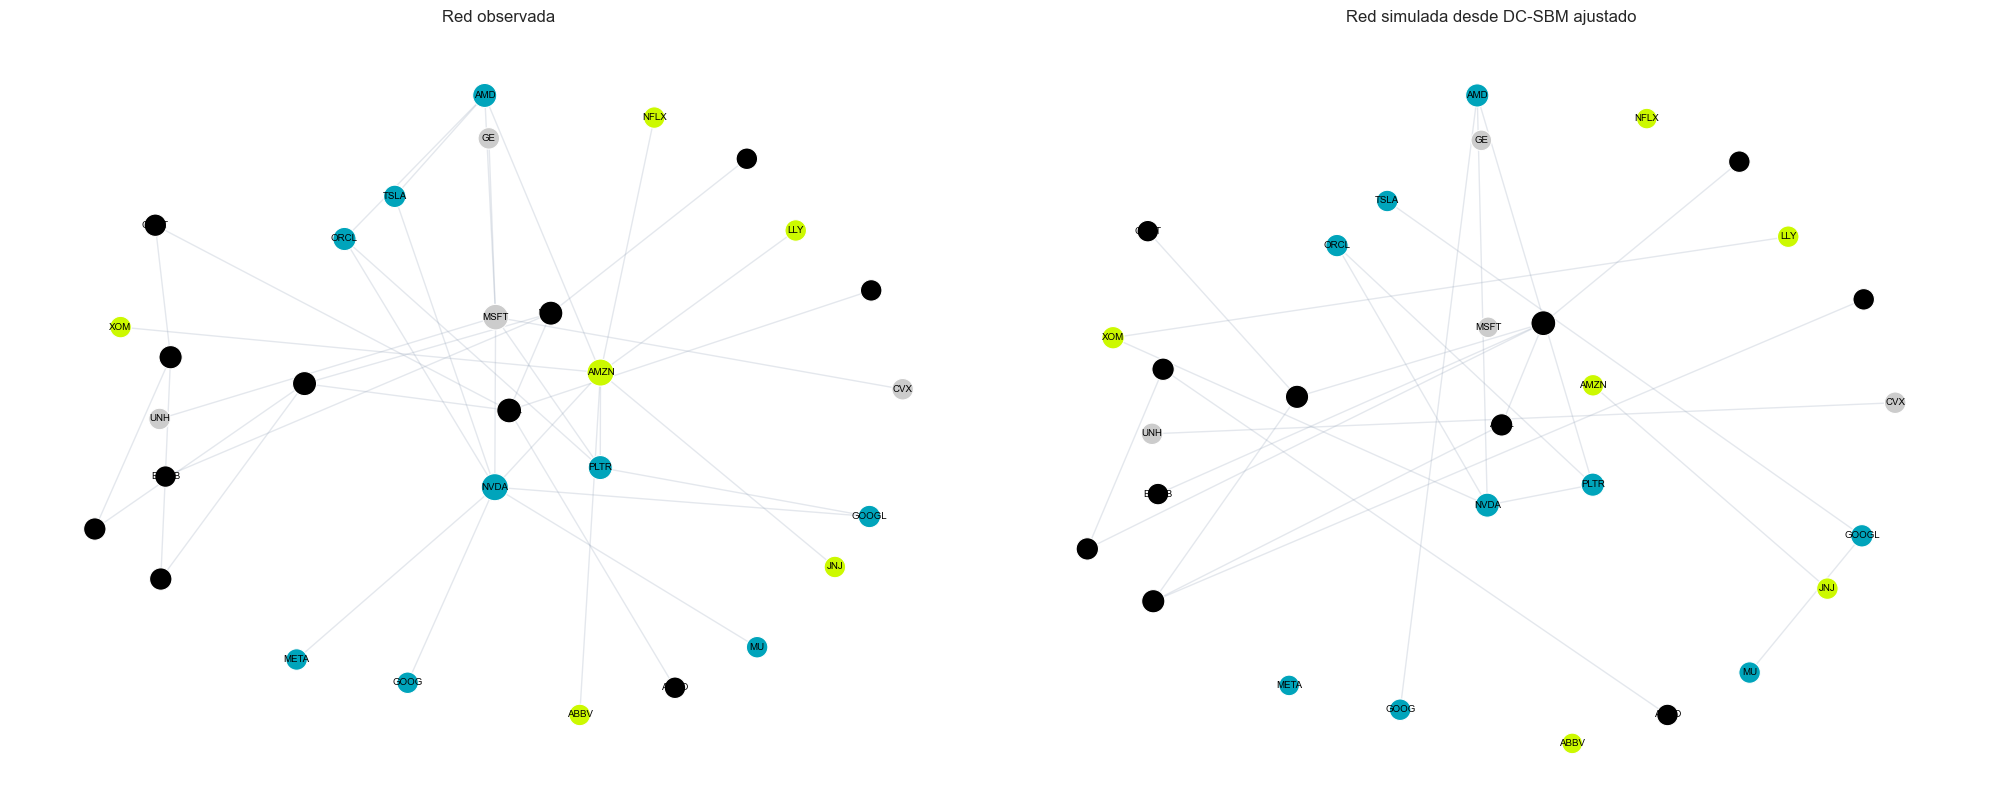

In [16]:

# Visualización: red observada vs. una red simulada desde el DC-SBM ajustado.
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, graph, title in [
    (axes[0], G_sp, "Red observada"),
    (axes[1], G_dcsbm_sim_sp, "Red simulada desde DC-SBM ajustado"),
]:
    draw_partition(
        ax,
        graph,
        fitted_stats["communities"],
        labels_sp,
        title=title,
        pos=pos_sp,
    )

plt.tight_layout()
plt.show()


<!-- interpretacion-sp500: red-simulada -->
### Lectura de la red observada vs. simulada

La red simulada reproduce la lógica de hubs, pero no necesariamente conserva todos los puentes observados. Esto se nota porque la simulación individual subestima bastante a **AMZN** y **MSFT**.

En la red real, AMZN conecta con empresas muy distintas (**NFLX, XOM, JNJ, ABBV, PLTR, AMD, NVDA**). Esa mezcla de relaciones es difícil de reproducir en una sola corrida Poisson porque varios $\lambda_{ij}$ son menores que $1$. Lo mismo ocurre con MSFT: sus enlaces con NVDA, AMD, PLTR, CVX, GE y UNH forman un puente entre tecnología e industrias no tecnológicas.

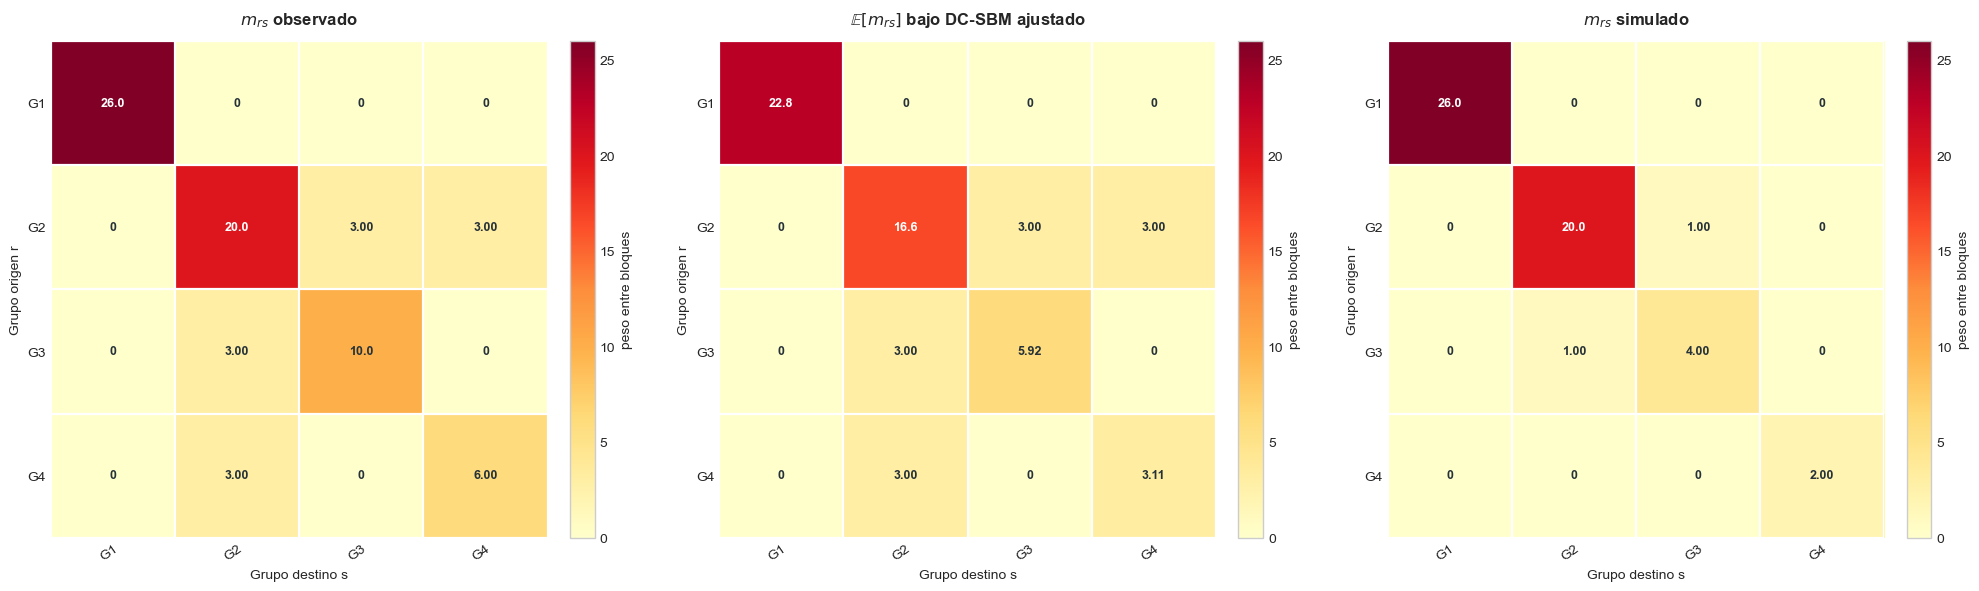

In [17]:

# Visualización de matrices de bloque: observado, esperado y simulado.
observed_m_rs = fitted_stats["m_rs"]
expected_m_rs = expected_m_rs_no_loops(fitted_stats)
simulated_m_rs = aggregate_m_rs_under_fixed_partition(G_dcsbm_sim_sp, fitted_stats, weight="weight")

matrices_to_plot = [
    (observed_m_rs, r"$m_{rs}$ observado"),
    (expected_m_rs, r"$\mathbb{E}[m_{rs}]$ bajo DC-SBM ajustado"),
    (simulated_m_rs, r"$m_{rs}$ simulado"),
]

group_names = fitted_stats["group_names"]
shared_norm = Normalize(*_matrix_color_limits([matrix for matrix, _ in matrices_to_plot]))
fig, axes = plt.subplots(1, 3, figsize=(20, 5.8), constrained_layout=True)

for ax, (matrix, title) in zip(axes, matrices_to_plot):
    _annotated_heatmap(
        ax,
        matrix,
        group_names,
        title,
        cmap="YlOrRd",
        norm=shared_norm,
        cbar_label="peso entre bloques",
    )

plt.show()


<!-- interpretacion-sp500: matrices-simulacion -->
### Interpretación de observado, esperado y simulado por bloques

En estas matrices, **peso entre bloques** significa:

$$
m_{rs}
=
\sum_{i,j} \delta_{g_i r}\delta_{g_j s}A_{ij}.
$$

Como la red es no dirigida, los bloques internos cuentan doble en la matriz dirigida: una arista dentro de $G_r$ aporta a las dos direcciones. Por eso $m_{rr}$ es peso dirigido interno, no simplemente número de aristas internas.

Lectura específica de la simulación individual:

- **G1-G1** observado es $26$, esperado $22.85$ y simulado $26$. El bloque retail/pagos se reproduce muy bien en esta corrida.
- **G2-G2** observado es $20$, esperado $16.57$ y simulado $20$. El bloque NVDA/plataformas también queda bien capturado internamente.
- **G3-G3** observado es $10$, esperado $5.92$ y simulado $4$. El bloque AMZN-satélites queda subestimado: la red real tiene más cierre alrededor de AMZN que esta simulación.
- **G4-G4** observado es $6$, esperado $3.11$ y simulado $2$. El bloque MSFT-CVX-GE-UNH también queda subestimado.
- Los cruces **G2-G3** y **G2-G4** observados valen $3$ cada uno, pero la simulación generó $1$ y $0$. Esta es la pérdida principal: el modelo individual simulado no recuperó todos los puentes entre NVDA/tecnología, AMZN y MSFT/enterprise.

Tickers con mayor grado observado


,ticker,grupo,k_i_observado,k_i_simulado,diferencia
3,AMZN,G3,8,1.0,-7.0
2,NVDA,G2,8,5.0,-3.0
1,MSFT,G4,6,0.0,-6.0
0,AAPL,G1,5,4.0,-1.0
13,WMT,G1,4,6.0,2.0
12,MA,G1,4,3.0,-1.0
25,AMD,G2,4,3.0,-1.0
19,PLTR,G2,4,3.0,-1.0
11,V,G1,3,2.0,-1.0
15,ORCL,G2,3,3.0,0.0


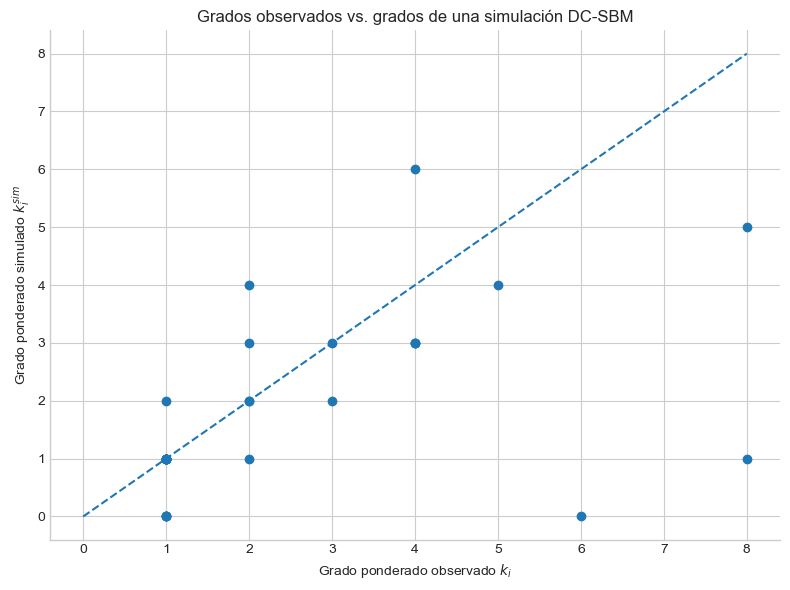

In [18]:

# Comparación de grados ponderados observados contra grados ponderados simulados.
degree_comparison_sp = pd.DataFrame(
    {
        "ticker": [labels_sp[node] for node in fitted_stats["nodes"]],
        "grupo": [f"G{fitted_stats['lookup'][node]+1}" for node in fitted_stats["nodes"]],
        "k_i_observado": [G_sp.degree(node, weight="weight") for node in fitted_stats["nodes"]],
        "k_i_simulado": [G_dcsbm_sim_sp.degree(node, weight="weight") for node in fitted_stats["nodes"]],
    }
)
degree_comparison_sp["diferencia"] = degree_comparison_sp["k_i_simulado"] - degree_comparison_sp["k_i_observado"]

print("Tickers con mayor grado observado")
display(degree_comparison_sp.sort_values("k_i_observado", ascending=False).head(15).round(4))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(degree_comparison_sp["k_i_observado"], degree_comparison_sp["k_i_simulado"])
max_degree = max(degree_comparison_sp["k_i_observado"].max(), degree_comparison_sp["k_i_simulado"].max())
ax.plot([0, max_degree], [0, max_degree], linestyle="--")
ax.set_xlabel(r"Grado ponderado observado $k_i$")
ax.set_ylabel(r"Grado ponderado simulado $k_i^{sim}$")
ax.set_title("Grados observados vs. grados de una simulación DC-SBM")
plt.tight_layout()
plt.show()


<!-- interpretacion-sp500: grados -->
### Interpretación de los grados observados vs. simulados

La comparación de grados muestra qué tan bien una simulación reproduce la centralidad de cada ticker.

- **AMZN** baja de $8$ observado a $1$ simulado. Es la mayor subestimación: en la red real AMZN conecta con satélites diversos y con el bloque tecnológico.
- **NVDA** baja de $8$ a $5$. El modelo reconoce que es hub, pero esta corrida no reproduce todos sus enlaces.
- **MSFT** baja de $6$ a $0$. Esto es una fluctuación fuerte de una sola simulación: los enlaces esperados de MSFT existen, pero varios tienen $\lambda<1$ y pueden no aparecer.
- **WMT** sube de $4$ a $6$ y **HD** de $2$ a $4$. En esta corrida, el bloque retail/pagos queda sobrerrepresentado.

La diagonal punteada representa igualdad perfecta entre grado observado y simulado. Los puntos debajo de la diagonal son empresas subestimadas; los de arriba son sobreestimadas. En esta simulación, los hubs transversales AMZN/MSFT quedan especialmente por debajo.

Resumen Monte Carlo con 200 redes simuladas


,peso_total_no_dirigido,aristas_positivas,proporcion_interna,error_frobenius_vs_esperado,error_frobenius_vs_observado
mean,30.5950,25.8450,0.8030,9.8004,11.8080
std,5.6472,4.2166,0.0716,3.5082,3.2485
min,19.0000,17.0000,0.6296,3.7425,3.7417
max,48.0000,38.0000,0.9714,20.3297,20.0998


,simulacion,peso_total_no_dirigido,aristas_positivas,proporcion_interna,error_frobenius_vs_esperado,error_frobenius_vs_observado
0,1,26.0,24,0.7692,10.2112,14.5602
1,2,24.0,21,0.7500,6.5905,13.1149
2,3,33.0,30,0.7273,4.4537,8.3666
3,4,31.0,23,0.8387,13.9460,14.3527
4,5,35.0,28,0.8000,10.7409,10.8628


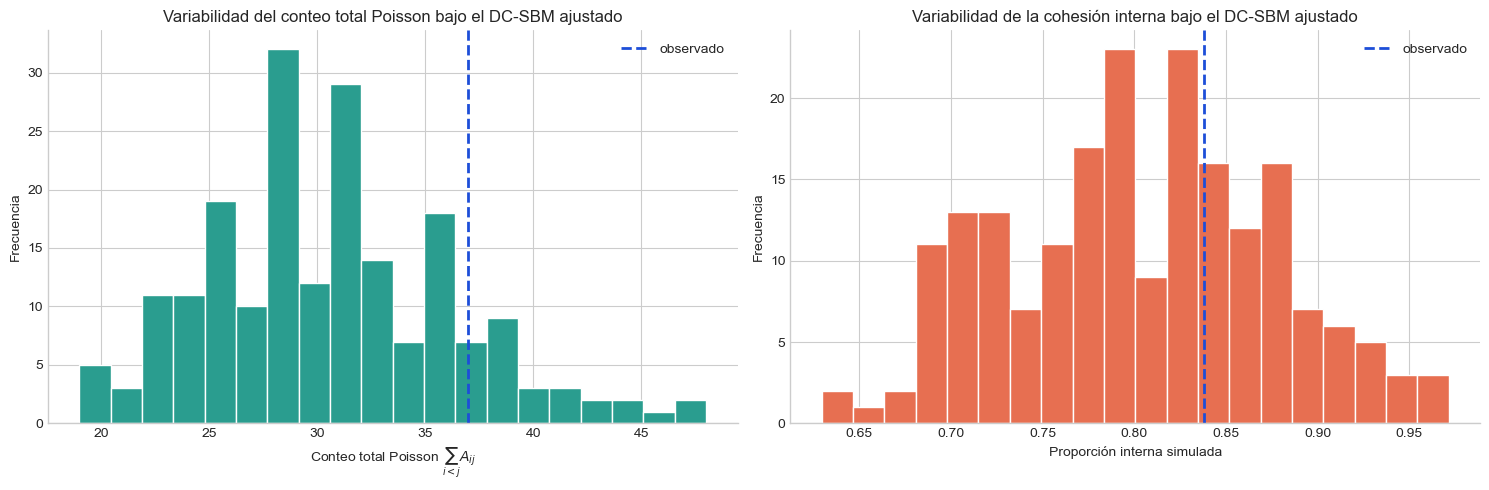

In [19]:

# Variabilidad Monte Carlo: muchas redes simuladas con los mismos parámetros ajustados.
def monte_carlo_dcsbm_summary(fitted_stats, n_simulations=200, seed=12345, weight="weight"):
    rng = np.random.default_rng(seed)
    rows = []
    observed_m_rs = fitted_stats["m_rs"]
    expected_m_rs = expected_m_rs_no_loops(fitted_stats)

    for simulation_id in range(n_simulations):
        sim_seed = int(rng.integers(0, 2**32 - 1))
        G_sim, _ = simulate_dcsbm_graph(fitted_stats, seed=sim_seed, weight=weight)
        sim_m_rs = aggregate_m_rs_under_fixed_partition(G_sim, fitted_stats, weight=weight)

        total_directed = sim_m_rs.sum()
        internal_share = np.trace(sim_m_rs) / total_directed if total_directed > 0 else np.nan
        frobenius_error_vs_expected = np.linalg.norm(sim_m_rs - expected_m_rs)
        frobenius_error_vs_observed = np.linalg.norm(sim_m_rs - observed_m_rs)

        rows.append(
            {
                "simulacion": simulation_id + 1,
                "peso_total_no_dirigido": G_sim.size(weight=weight),
                "aristas_positivas": G_sim.number_of_edges(),
                "proporcion_interna": internal_share,
                "error_frobenius_vs_esperado": frobenius_error_vs_expected,
                "error_frobenius_vs_observado": frobenius_error_vs_observed,
            }
        )

    return pd.DataFrame(rows)


mc_dcsbm_sp = monte_carlo_dcsbm_summary(fitted_stats, n_simulations=200, seed=2026, weight="weight")

mc_summary_sp = mc_dcsbm_sp.drop(columns=["simulacion"]).agg(["mean", "std", "min", "max"])
print("Resumen Monte Carlo con 200 redes simuladas")
display(mc_summary_sp.round(4))

display(mc_dcsbm_sp.head().round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(mc_dcsbm_sp["peso_total_no_dirigido"], bins=20, color="#2a9d8f", edgecolor="white")
axes[0].axvline(G_sp.size(weight="weight"), linestyle="--", color="#1d4ed8", linewidth=2, label="observado")
axes[0].set_xlabel(r"Conteo total Poisson $\sum_{i<j} A_{ij}$")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Variabilidad del conteo total Poisson bajo el DC-SBM ajustado")
axes[0].legend()

axes[1].hist(mc_dcsbm_sp["proporcion_interna"], bins=20, color="#e76f51", edgecolor="white")
axes[1].axvline(fitted_stats["internal_share"], linestyle="--", color="#1d4ed8", linewidth=2, label="observado")
axes[1].set_xlabel("Proporción interna simulada")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Variabilidad de la cohesión interna bajo el DC-SBM ajustado")
axes[1].legend()

plt.tight_layout()
plt.show()


<!-- interpretacion-sp500: monte-carlo -->
### Interpretación Monte Carlo

En el histograma de peso total, **peso** significa:

$$
\text{peso total no dirigido}
=
\sum_{i<j} A_{ij}^{\mathrm{sim}}.
$$

Como usamos el modelo Poisson,

$$
A_{ij}^{\mathrm{sim}}
\sim
\operatorname{Poisson}(\lambda_{ij}),
$$

entonces $A_{ij}^{\mathrm{sim}}$ puede ser $0,1,2,3,\ldots$. Si entre dos empresas sale $A_{ij}=3$, se interpreta como tres multiaristas o como una arista con peso $3$.

En una red simple, $\sum_{i<j}A_{ij}$ sería el número total de aristas. Aquí es casi lo mismo conceptualmente, pero permitiendo conteos Poisson mayores que $1$.

La línea punteada azul del primer histograma es el valor observado:

$$
\sum_{i<j} A_{ij}^{\mathrm{obs}}=37.
$$

En las 200 simulaciones, el peso total medio es $30.60$, con percentiles aproximados 5%-95% de $22.00$ a $40.05$. La red observada ($37$) está por encima de la media, pero todavía dentro del rango típico alto de las simulaciones. Eso sugiere que el DC-SBM no falla en escala total, aunque tiende a generar redes algo más escasas.

La segunda gráfica muestra la proporción interna. Las simulaciones tienen media $0.803$, mientras que la red observada tiene $0.8378$. La observada es algo más asortativa que el promedio simulado, pero no de forma extrema. En contexto económico: los bloques proveedor-cliente reales están bastante cerrados, aunque los puentes entre NVDA, AMZN y MSFT también son importantes.

## Lectura de la simulación

La red simulada conserva la lógica estadística del DC-SBM ajustado: los nodos con mayor $k_i$ tienden a recibir más enlaces y los pares de grupos con mayor $\hat\omega_{rs}$ tienden a concentrar más conexiones. Aun así, la red simulada no tiene que ser idéntica a la observada, porque cada peso se genera aleatoriamente mediante una variable Poisson.

La comparación relevante no es enlace por enlace exacto, sino de patrones agregados:

$$
A_{ij}^{\mathrm{sim}}\sim \operatorname{Poisson}\left(
\hat\omega_{g_i g_j}\frac{k_i k_j}{2m}
\right)
\quad\Longrightarrow\quad
\mathbb{E}[A_{ij}^{\mathrm{sim}}]
=
\hat\omega_{g_i g_j}\frac{k_i k_j}{2m}.
$$

Por eso, si el ajuste es razonable, las matrices de bloque simuladas $m_{rs}^{\mathrm{sim}}$ deben fluctuar alrededor de sus valores esperados bajo el modelo.